# Inferencial Statistics Analysis

## Quick Overview

This analysis was conducted with the aim of analysing and understanding the productivity of the employees of a company and how different factors affect the values of the productivity, overtime and consequently the costs of running the company. By preprocessing the data and conducting an Exploratory Data Analysis it was much easier to understand the data and later I could benefit from that by choosing the most appropriate approach for each given context. In this step I could understand even though there were no missing values or duplicates, I had categorical variables that should be converted into numerical variables and my variables were not normally distributed. This had to be then addressed later.

This ipynb file contains the answers and rationale for the business questions. The rationale is given both in the form of markdown and comments. I made my approaches adapted to the context of each problem.      

The Report can be found both at the end of this file and in the Word Document. You can also find the following sections in this file:

* Import Statments - Are located near the title of each section. This is where I import most of the libraries that I ended up using, a few other libraries are imported later on when needed.
* Data Collection/Loading - where I collect the data from the source (csv file) and load it in the form of a Pandas Dataframe
* EDA - where I perform a quick Exploratory Data Analysis in order to better understand the given dataset and select the best way to approach each question making use of the most appropriate resources. This way my approach gets more realistic and suitable for the context of the dataset.
* Questions - The questionas and resolutions for the questions to solve.
* Summary, Conclusions and Disclaimer  (Report) - limitations of the Analysis and wrap up.

## Questions
### Inferential Statistics
The company believes implemented new machines will reduce the average overtime (in minutes) that the workers will do, which will lead to a cost reduction in the end. They tried it in a group of 200 workers, which shows an average overtime of 6300 minutes. 
#### Question 1
Can we say that the company is right in it's belief? 

#### Question 2
What is the real average productivity of these workers each day of the week? Is there any difference between the days? 

#### Question 3
What are the factors that influence employee’s productivity?
#### Reporting
Text report summarizing analysis rationale key points 

# Import Statements
Here I import some the necessary libraries

In [1]:
# For data manipulation and wrangling
import pandas as pd
import numpy as np

# For visualization
import matplotlib.pyplot as plt
import seaborn as sns

# For statistical operations
import scipy.stats as stats
from statsmodels.formula.api import ols
import statsmodels.api as sm

# Data Collection/Loading
Here I load the data set from the source, which is a csv file. Then through the EDA I can get a quick overview of what my data looks like in general before getting started to using it to answer the questions.

In [2]:
pd.set_option("display.max_columns", 50)   # This code is to display up to 50 columns without cutting
sns.set_style(style="darkgrid")            # Set a style for my plots using seaborn
dataframe = pd.read_csv("garments_worker_productivity.csv",)

# EDA - Exploratory Data Analysis

In [3]:
# Display the first 5 observations of the data
dataframe.head()

,department,day,team,targeted_productivity,smv,wip,over_time,incentive,idle_time,idle_men,no_of_style_change,no_of_workers,actual_productivity
0,sweing,Thursday,8,0.8,26.16,1108,7080,98,0.0,0,0,59.0,0.940725
1,sweing,Thursday,11,0.8,11.41,968,3660,50,0.0,0,0,30.5,0.800570
2,sweing,Thursday,12,0.8,11.41,968,3660,50,0.0,0,0,30.5,0.800570
3,sweing,Thursday,6,0.8,25.90,1170,1920,50,0.0,0,0,56.0,0.800382
4,sweing,Thursday,7,0.8,25.90,984,6720,38,0.0,0,0,56.0,0.800125


In [4]:
# Display the last 5 observations of the data. This is because sometimes there are some errors or missing values in the last observations
dataframe.tail()

,department,day,team,targeted_productivity,smv,wip,over_time,incentive,idle_time,idle_men,no_of_style_change,no_of_workers,actual_productivity
686,sweing,Wednesday,4,0.75,26.82,1054,7080,45,0.0,0,0,59.0,0.750051
687,sweing,Wednesday,5,0.70,26.82,992,6960,30,0.0,0,1,58.0,0.700557
688,sweing,Wednesday,8,0.70,30.48,914,6840,30,0.0,0,1,57.0,0.700505
689,sweing,Wednesday,6,0.70,23.41,1128,4560,40,0.0,0,1,38.0,0.700246
690,sweing,Wednesday,7,0.65,30.48,935,6840,26,0.0,0,1,57.0,0.650596


In [5]:
# Provide information about the dataset such as null values, datatype and names of columns
dataframe.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 691 entries, 0 to 690
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   department             691 non-null    object 
 1   day                    691 non-null    object 
 2   team                   691 non-null    int64  
 3   targeted_productivity  691 non-null    float64
 4   smv                    691 non-null    float64
 5   wip                    691 non-null    int64  
 6   over_time              691 non-null    int64  
 7   incentive              691 non-null    int64  
 8   idle_time              691 non-null    float64
 9   idle_men               691 non-null    int64  
 10  no_of_style_change     691 non-null    int64  
 11  no_of_workers          691 non-null    float64
 12  actual_productivity    691 non-null    float64
dtypes: float64(5), int64(6), object(2)
memory usage: 70.3+ KB


In [6]:
# Displays discriptive statistics of the data
dataframe.describe(include="all")

,department,day,team,targeted_productivity,smv,wip,over_time,incentive,idle_time,idle_men,no_of_style_change,no_of_workers,actual_productivity
count,691,691,691.000000,691.000000,691.000000,691.000000,691.000000,691.000000,691.000000,691.000000,691.000000,691.000000,691.000000
unique,1,6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,sweing,Wednesday,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,691,119,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,6.520984,0.723980,23.245412,1190.465991,6508.205499,44.483357,1.264834,0.639653,0.260492,52.445731,0.722013
std,NaN,NaN,3.458333,0.102006,6.976497,1837.455001,2864.505604,27.596591,16.712923,4.283652,0.537185,9.417353,0.154784
min,NaN,NaN,1.000000,0.070000,10.050000,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,26.000000,0.233705
25%,NaN,NaN,4.000000,0.700000,18.790000,774.500000,4560.000000,30.000000,0.000000,0.000000,0.000000,52.000000,0.661470
50%,NaN,NaN,6.000000,0.750000,22.520000,1039.000000,6840.000000,45.000000,0.000000,0.000000,0.000000,57.000000,0.750608
75%,NaN,NaN,10.000000,0.800000,28.080000,1252.500000,7200.000000,60.000000,0.000000,0.000000,0.000000,58.000000,0.800402


In [7]:
# Check for null values on the dataset. In this case there are none
dataframe.isnull().sum()

department               0
day                      0
team                     0
targeted_productivity    0
smv                      0
wip                      0
over_time                0
incentive                0
idle_time                0
idle_men                 0
no_of_style_change       0
no_of_workers            0
actual_productivity      0
dtype: int64

In [8]:
# Check for any duplicated observation in the dataset
dataframe.duplicated().any()

False

#### Univariate Analysis
Here I will conduct Univariate analysis in order to independently understand each variable and their distribution. This will also be useful to understadn whether I need to later normalize the data or not

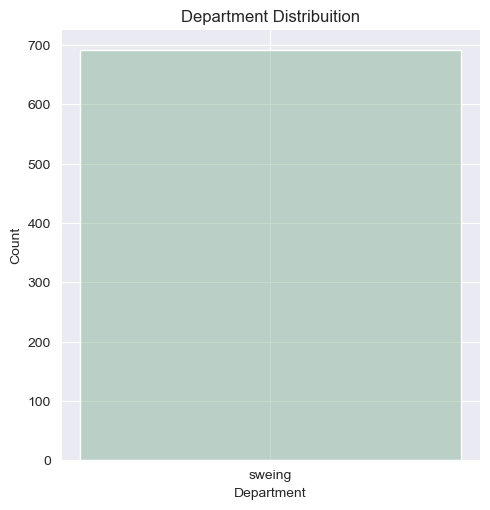

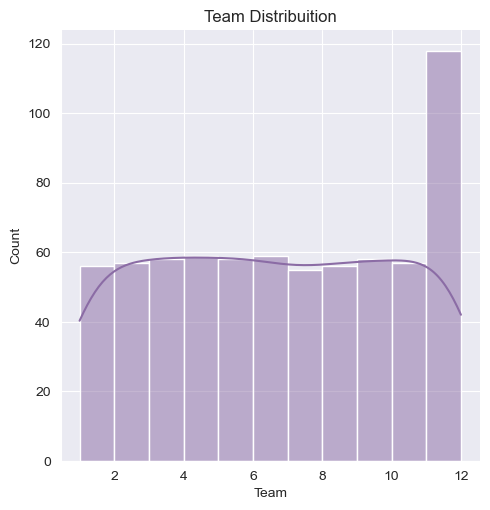

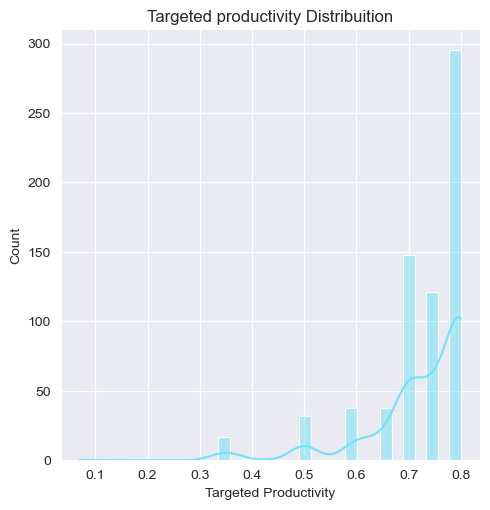

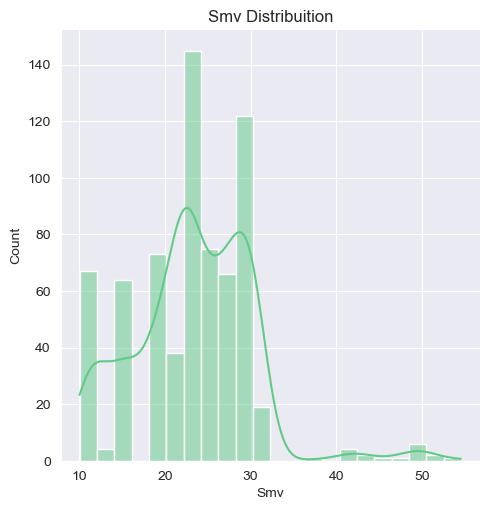

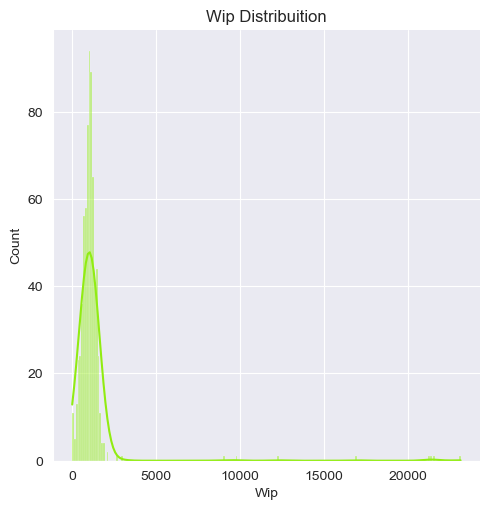

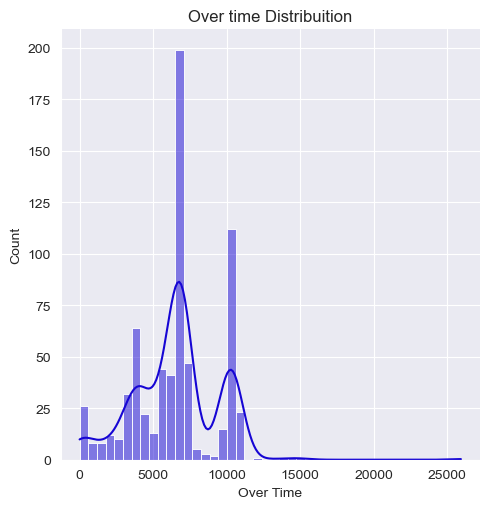

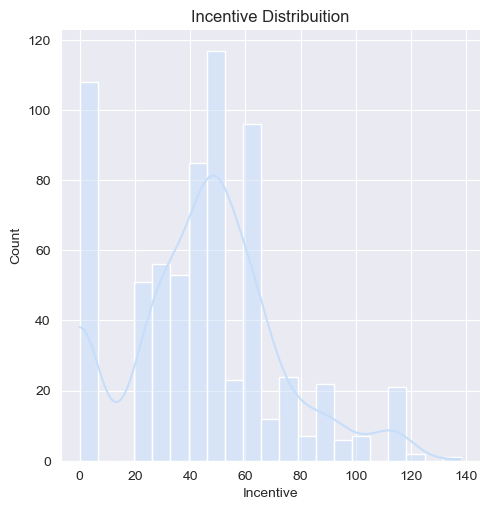

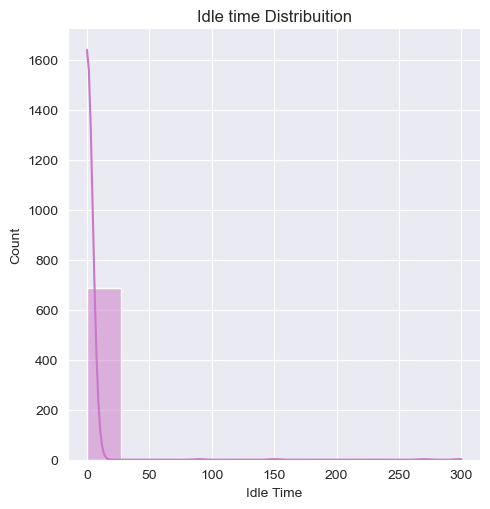

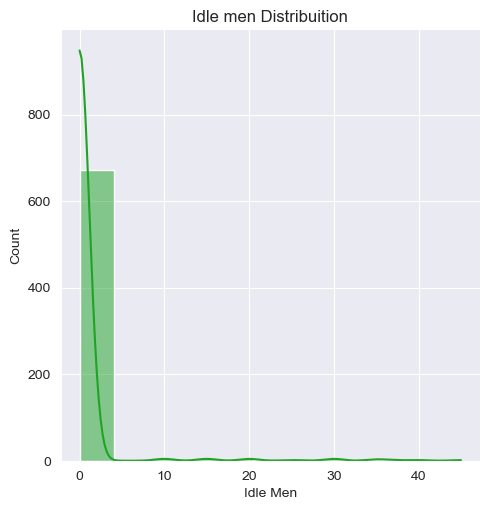

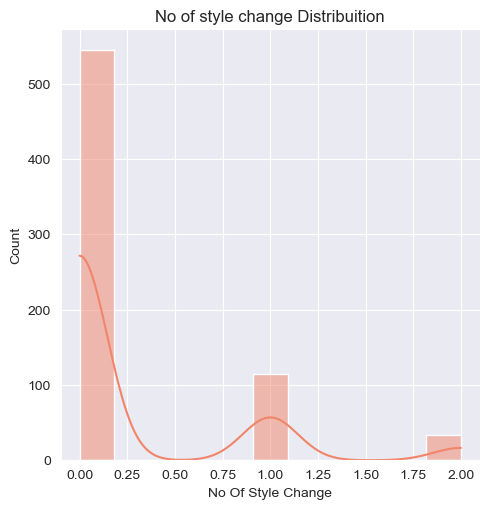

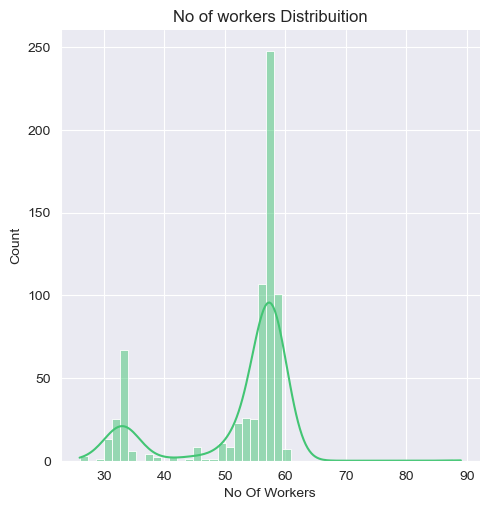

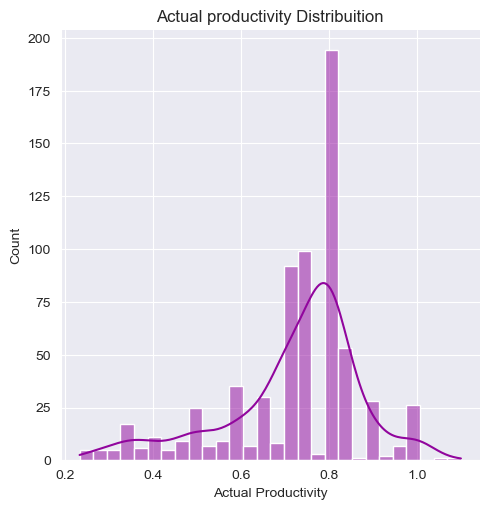

In [9]:
np.random.seed(0)
for c in dataframe.columns.delete([1]):  # Goes through all the columns of the dataset except the day column
    sns.displot(data=dataframe[c], kde=True, color=(np.random.rand(1)[0], np.random.rand(1)[0], np.random.rand(1)[0]))
    plt.xlabel(c.title().replace("_", " "))
    plt.title(f"{c.capitalize().replace("_", " ")} Distribuition")
    plt.show()

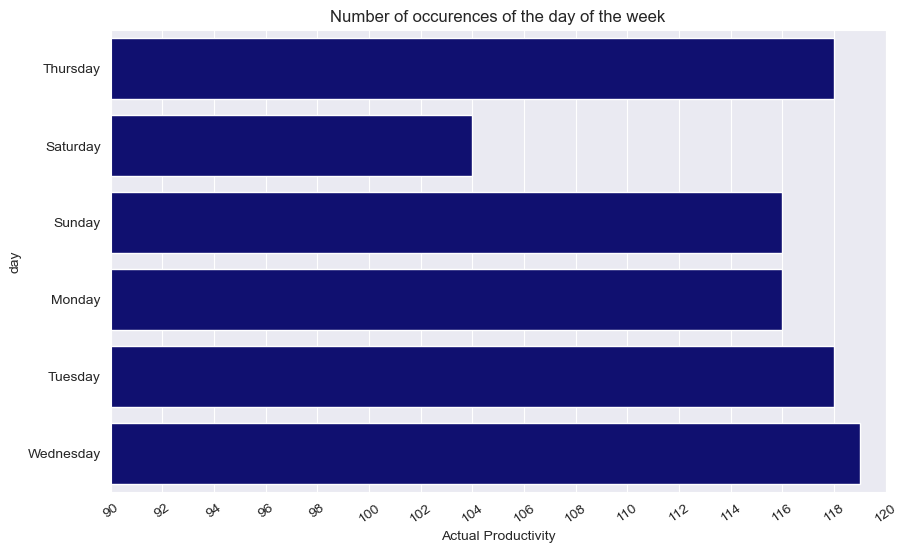

In [10]:
# Plot the number of occurences of the day of the week
plt.figure(figsize=(10,6))
sns.countplot(dataframe.iloc[:,1], color="navy")
plt.xlabel(c.title().replace("_", " "))
plt.xticks(np.linspace(90, 120, 16), rotation=35)
plt.xlim((90, 120))
plt.title("Number of occurences of the day of the week")
plt.show()

In [11]:
dataframe

,department,day,team,targeted_productivity,smv,wip,over_time,incentive,idle_time,idle_men,no_of_style_change,no_of_workers,actual_productivity
0,sweing,Thursday,8,0.80,26.16,1108,7080,98,0.0,0,0,59.0,0.940725
1,sweing,Thursday,11,0.80,11.41,968,3660,50,0.0,0,0,30.5,0.800570
2,sweing,Thursday,12,0.80,11.41,968,3660,50,0.0,0,0,30.5,0.800570
3,sweing,Thursday,6,0.80,25.90,1170,1920,50,0.0,0,0,56.0,0.800382
4,sweing,Thursday,7,0.80,25.90,984,6720,38,0.0,0,0,56.0,0.800125
...,...,...,...,...,...,...,...,...,...,...,...,...,...
686,sweing,Wednesday,4,0.75,26.82,1054,7080,45,0.0,0,0,59.0,0.750051
687,sweing,Wednesday,5,0.70,26.82,992,6960,30,0.0,0,1,58.0,0.700557
688,sweing,Wednesday,8,0.70,30.48,914,6840,30,0.0,0,1,57.0,0.700505
689,sweing,Wednesday,6,0.70,23.41,1128,4560,40,0.0,0,1,38.0,0.700246


# Question 1

The company believes implemented new machines will reduce the average overtime (in minutes) that the workers will do, which will lead to a cost reduction in the end. They tried it in a group of 200 workers, which shows an average overtime of 6300 minutes. 

Can we say that the company is right in it's belief? 

### Hypothesis Rationale:
Since we want to objectively assure whether there is or not enough evidence in our sample to support the belief or claim of the company, we therefore know that we want to perform a one-sample statistical test. To formulate the hyphothesis we first have to get the current average overtime of all the workers (population mean). Since, we know that the company believes that by implementing the new machines the average overtime of the workers will decrease, the null hypothesis will state that the average overtime will either remain the same or even increase. Consequently, the alternative hypothesis will state that the average overtime will decrease, as per the belief of the company.

### Hyphotesis Definition:

##### H0: µ >= 6508.206
 
##### H1: µ < 6508.206

In [12]:
mu = dataframe.over_time.mean()    # This is the mean of the population (µ)
f"µ = {mu}"

'µ = 6508.205499276411'

### Other values we have available:

In [13]:
sigma = dataframe.over_time.std()  # This is the population STD
f"sigma = {sigma}" 

'sigma = 2864.5056039062483'

In [14]:
x_bar = 6300                       # This is the mean of the sample
n = 200                            # This is the sample size
alpha = 0.05                       # Significance level

In [15]:
dataframe.describe()

,team,targeted_productivity,smv,wip,over_time,incentive,idle_time,idle_men,no_of_style_change,no_of_workers,actual_productivity
count,691.000000,691.000000,691.000000,691.000000,691.000000,691.000000,691.000000,691.000000,691.000000,691.000000,691.000000
mean,6.520984,0.723980,23.245412,1190.465991,6508.205499,44.483357,1.264834,0.639653,0.260492,52.445731,0.722013
std,3.458333,0.102006,6.976497,1837.455001,2864.505604,27.596591,16.712923,4.283652,0.537185,9.417353,0.154784
min,1.000000,0.070000,10.050000,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,26.000000,0.233705
25%,4.000000,0.700000,18.790000,774.500000,4560.000000,30.000000,0.000000,0.000000,0.000000,52.000000,0.661470
50%,6.000000,0.750000,22.520000,1039.000000,6840.000000,45.000000,0.000000,0.000000,0.000000,57.000000,0.750608
75%,10.000000,0.800000,28.080000,1252.500000,7200.000000,60.000000,0.000000,0.000000,0.000000,58.000000,0.800402
max,12.000000,0.800000,54.560000,23122.000000,25920.000000,138.000000,300.000000,45.000000,2.000000,89.000000,1.100484


### Approach choice

Since we have the population standard deviation and the number of observations is bigger than 30 I chose to use the Z-score which will give, for this context, values more accurate and less biased. Even though I found out that the population distribuition is not normal, according to the Central Limit Theorem, by having a sample size big enough we can still perform z-test or t-test because as the sample size grows the sampling distribution will become approximately normal. So that's why I will still proceed with the z-test even though the distribuition of the population is not normal.

In [16]:
# Z-score
z = (x_bar - mu) / (sigma / (n -1) ** 0.5)
z

-1.0253427341184451

<Axes: xlabel='over_time', ylabel='Count'>

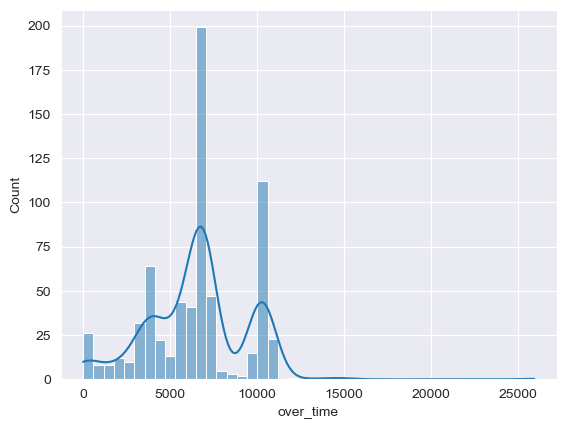

In [17]:
# Data is not normaly distributed but I will proceed any ways to get the critical values

sns.histplot(dataframe.over_time, kde=True)

In [18]:
# Critical Value
critical = stats.norm.ppf(alpha)  # We want a left tailed z-score for the reduction of the overtime. That's why I don't use 1-alpha

In [19]:
f"Rejection zone is x <= {critical}"

'Rejection zone is x <= -1.6448536269514729'

In [20]:
"Final Answer: " + ("Reject H0 because there is enough statistical difference" if abs(z) >= abs(critical) else "Fail to reject H0 because there is no significant statistical difference to state that the machines will relevantly decrease the average overtime of the workers ")

'Final Answer: Fail to reject H0 because there is no significant statistical difference to state that the machines will relevantly decrease the average overtime of the workers '

### Answer:

With 95% confidence, we fail to reject the hypothesis that overtime has been reduced. 

# Question 2

What is the real average productivity of these workers each day of the week? Is there any difference between the days? 


In [21]:
prod_df = dataframe[["day", "actual_productivity"]]  # Productivity and Day Dataframe

### Real Average productivity:

Below I created a list of dictionaries which store some statistical values for each day of the week. Each dictionary represent one day of the week. This way I can present in a table the real average productivity for each day individually and their respective confidence interval. Therefore I take the data from each day as a population and from there I subset them in samples of the size 25 in order to perform t-test if I want to. Then I use those samples as representative of each population to get the real average productivity. From there we could perform multiple hypothesis testing for two populations to see if there is any difference between any groups however this is not so feasible so an ANOVA test will be much more efficient.

In [ ]:
# Here I create a list of dictionaries to store statistical values for each Day
np.random.seed(0)

days_statistics = []

for day in prod_df.day.unique():
    day_data = prod_df["actual_productivity"][prod_df.day == day]
    
    # Drawing one sample to reuse it
    sample = day_data.sample(25)
    
    pop_mean = day_data.mean()
    pop_std  = day_data.std()
    samp_mean = sample.mean()
    samp_std  = sample.std()
    
    # Standard error: std / sqrt(n)
    se = samp_std / (25 ** 0.5)
    
    t_score = (samp_mean - pop_mean) / se

    ci = (samp_mean - t_score * se, samp_mean + t_score * se)
    
    days_statistics.append({
        "day": day,
        "population mean": pop_mean,
        "population std": pop_std,
        "sample mean": samp_mean,
        "sample std": samp_std,
        "t-score": t_score,
        "confidence interval": ci,
    })
    

In [23]:
# Here I create a Dataframe to become easier to visualize the statistics for each day
statistics_day = pd.DataFrame({"day": [d for d in prod_df.day.unique()],
                               "pop_mean": [d["population mean"] for d in days_statistics],
                              "pop_std": [d["population std"] for d in days_statistics],
                              "sample_mean": [d["sample mean"] for d in days_statistics],
                              "sample_std": [d["sample std"] for d in days_statistics],
                              "t_score": [d["t-score"] for d in days_statistics],
                              "confidence_interval": [d["confidence interval"] for d in days_statistics]})

#### Real Average Productivity for each day of the week:

In [24]:
statistics_day.iloc[:,[0, 3,4, 6]]

,day,sample_mean,sample_std,confidence_interval
0,Thursday,0.694311,0.148194,"(0.6439060147178259, 0.7517569991947056)"
1,Saturday,0.750328,0.152197,"(0.746221477522523, 0.7555889931858423)"
2,Sunday,0.743633,0.124807,"(0.7314059746777323, 0.6740103802190914)"
3,Monday,0.732855,0.134686,"(0.6893287109517853, 0.7670138388376)"
4,Tuesday,0.700971,0.155327,"(0.7105338764938427, 0.6874258669755264)"
5,Wednesday,0.760243,0.197784,"(0.7639756105221537, 0.7390260602943683)"


In [25]:
statistics_day

,day,pop_mean,pop_std,sample_mean,sample_std,t_score,confidence_interval
0,Thursday,0.710772,0.168925,0.694311,0.148194,0.345510,"(0.6439060147178259, 0.7517569991947056)"
1,Saturday,0.734080,0.144047,0.750328,0.152197,0.714778,"(0.746221477522523, 0.7555889931858423)"
2,Sunday,0.713549,0.149421,0.743633,0.124807,-0.067850,"(0.7314059746777323, 0.6740103802190914)"
3,Monday,0.724169,0.147301,0.732855,0.134686,-0.224972,"(0.6893287109517853, 0.7670138388376)"
4,Tuesday,0.728115,0.151940,0.700971,0.155327,0.140971,"(0.7105338764938427, 0.6874258669755264)"
5,Wednesday,0.722712,0.165911,0.760243,0.197784,-1.017596,"(0.7639756105221537, 0.7390260602943683)"


In [26]:
# This will help me understand the cyclicity of the data and understand if the observations of each day are independent from each other
def return_index_of_blips(data: pd.DataFrame) -> list:
    """Returns a list of indexes where there was an abrupt change of values. 
    My rationale is the following: I created a zip to keep track of both the values and indexes of the values. 
    This way I could compare the current values with the previous ones in order to see if there was an abrupt change (a change > 0.15). 
    If there was a big change then the index where this change occur will be returned to a list."""
    return[index for v, index in zip(list(data["actual_productivity"]),
                              [n for n in range(118)]) if abs(v - list(data["actual_productivity"])[index - 1]) > 0.15 and index > 0]

In [27]:
print("Weeks where productivity increased:\n")
for day in prod_df.day.unique():
    space = (15 - len(day)) * " " if day != "Saturday" else (19 - len(day)) * " "   # This code is to align the lists
    if day == "Wednesday":
        space = (11 - len(day)) * " "
    print(f"{day}:{space}{return_index_of_blips(prod_df[prod_df.day == day])}")

Weeks where productivity increased:

Thursday:       [11, 12, 22, 24, 36, 48, 56, 59, 71, 73, 83, 94, 95, 104, 107, 116]
Saturday:           [12, 23, 24, 36, 47, 48, 58, 60, 71, 72, 73, 82, 94]
Sunday:         [12, 24, 35, 36, 48, 57, 59, 69, 71, 72, 82, 90, 93, 105]
Monday:         [11, 12, 23, 24, 35, 36, 46, 47, 56, 57, 59, 69, 71, 72, 80, 82, 92, 93, 104]
Tuesday:        [12, 23, 24, 33, 35, 46, 58, 68, 70, 71, 80, 82, 92, 93, 94, 105, 106]
Wednesday:  [11, 12, 23, 35, 43, 46, 47, 58, 59, 71, 80, 83, 84, 95, 104, 107]


In [28]:
print("As we can see below the amount of observations for each day of the week is not the same, but for the sake of the visualization I will still proceed by reseting the indexes even though they might not match anymore. I will still proceed with the visualizations.\n")
for day in prod_df.day.unique():
    print(day, ": ", prod_df[prod_df.day == day].shape)

As we can see below the amount of observations for each day of the week is not the same, but for the sake of the visualization I will still proceed by reseting the indexes even though they might not match anymore. I will still proceed with the visualizations.

Thursday :  (118, 2)
Saturday :  (104, 2)
Sunday :  (116, 2)
Monday :  (116, 2)
Tuesday :  (118, 2)
Wednesday :  (119, 2)


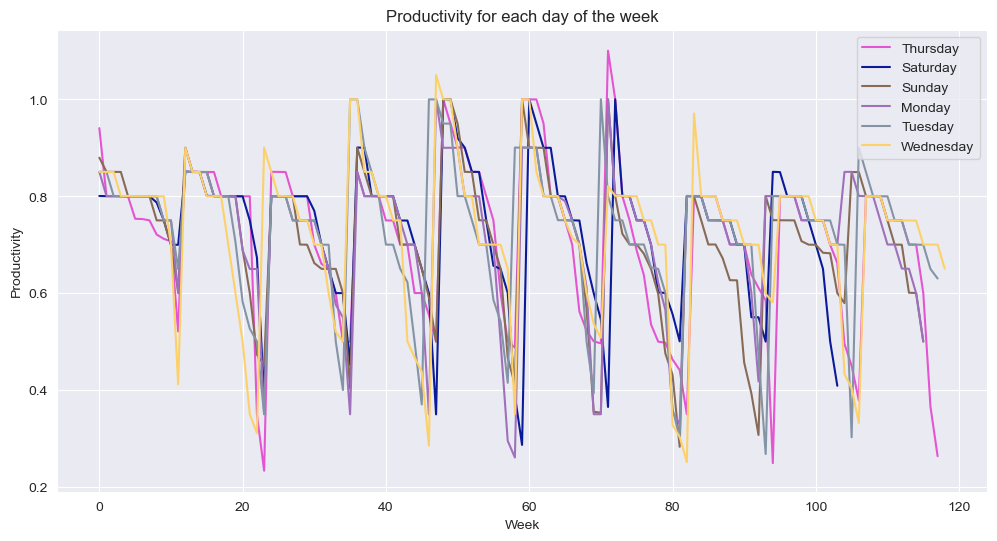

In [29]:
# Here I use the seed function to preserve the state of randomness to avoid different colors which could make it difficult to see
np.random.seed(6)   

# Generate colors each day
colors = [(np.random.rand(1)[0], np.random.rand(1)[0], np.random.rand(1)[0]) for i in prod_df.day.unique()] 

plt.figure(figsize=(12,6))
for day, c in zip(prod_df.day.unique(), colors): 
    plt.plot(prod_df[prod_df.day == day].reset_index(drop=True).index,
             "actual_productivity", 
             data=prod_df[prod_df.day == day].reset_index(drop=True), color=c,)
    plt.title("Productivity for each day of the week")
    plt.legend(prod_df.day.unique())
    plt.xlabel("Week")
    plt.ylabel("Productivity")

#### What can we observe above?
As we can see above the productivity follows a particular periodicity (a cycle) to which every day of the week is somewhat bound to. Thus we can understand that there are "common" weeks where the productivity is very low for every day of the week then these weeks are followed by big values in the productivity again. This shows that not every observation on each day is independent from the other, given they they appear as a cycle. In a very high-level way I would also say that there seem to be some slight difference between some days but now we have to check if this differences are statistically significant.
#### Let's now statistically check whether there are differences in productivity between the days of the week.


### Method choice and approach:
Given that we want to understand if there is any statistical difference between more than 2 groups (6 days of the week) for one factor (Actual Productivity), we want to perform a One-Way ANOVA test. However to perform the ANOVA test we have to ensure 3 factors otherwise our result will not be accurate and correct for this given context and another methods and tests should be utilized:

1. The observations for each day of the week are independent from each other **(Sample Independence)**
2. The data from each day shows a normal distribution **(Variables Normal Distribution)**
3. The variances from each day are approximately the same **(Approximately same Variance between variables)**

We should always make sure this 3 factors are fulfilled because as a parametric test the ANOVA test assumes independece and randomness between the samples, normal population distribution and similarity in the samples variance.

##### For the sake of the analysis we will assume sample independence and proceed to the other two factors, even though we know that the cyclical nature of the values suggest dependence of each observation.
Since we know that we want to perform ANOVA test due to the nature of the problem raised and we are assuming sample independence, we can start by formulating the hypothesis for the distribution:

### Hypothesis Rationale:
As we want to undestand whether there is statistical significant difference between the productivity for each day, the null hypothesis will state that there will be not enough difference between the productivity between each day, whereas the alternative hypothesis will state that at least one day will differ from the others. 

### Hypothesis Definition:
* H0: There will be no statistical difference in the productivity between the different days of the week: µTuesday=µWednesday=µThursday=µSaturday=µSunday=µMonday

* H1: There will be at least on day where the productivity statistically differs from the others.

#### Normal Distribution

* H0: Each Day of the week (Each Population) is normally distributed
* H1: There will be at least one day not normally distributed.

With the plots below we can see that generally the days don't seem to have a tight normal distribution. But lets perform Shapiro tests to statistically test the normality of the data.

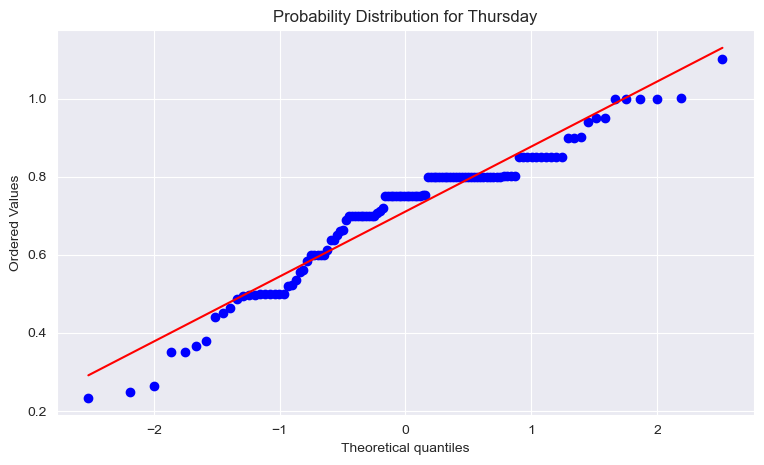

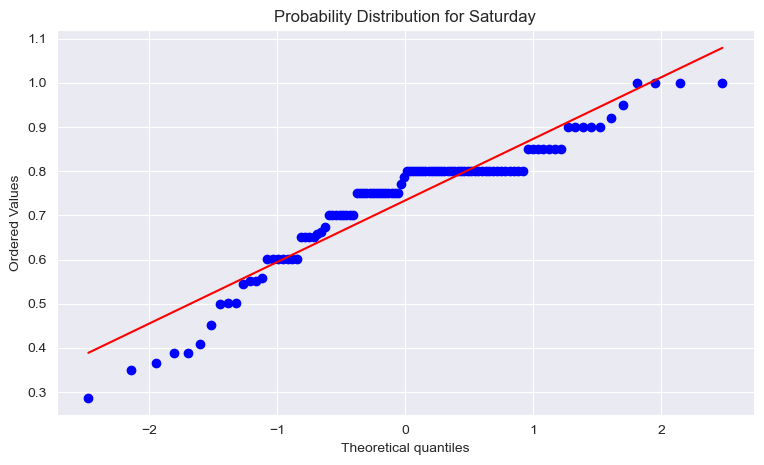

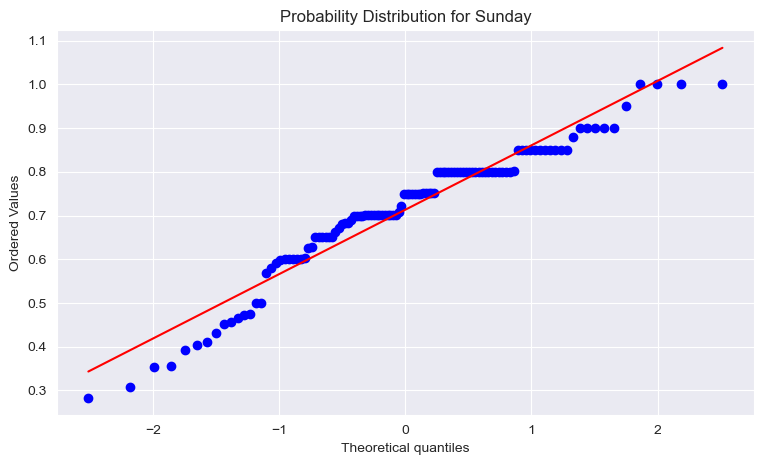

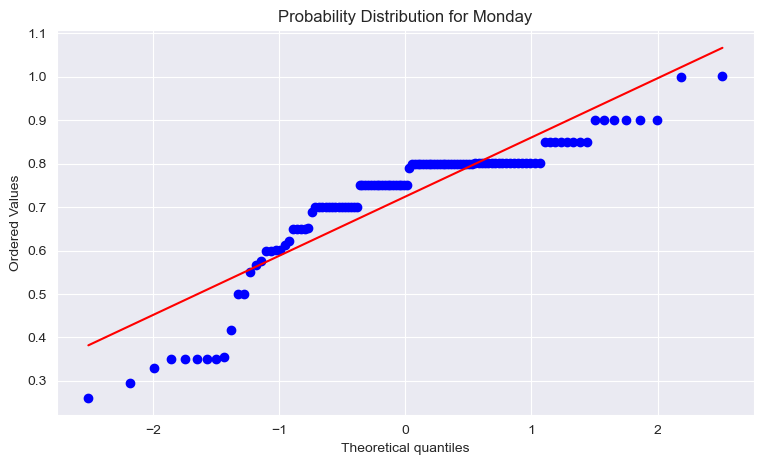

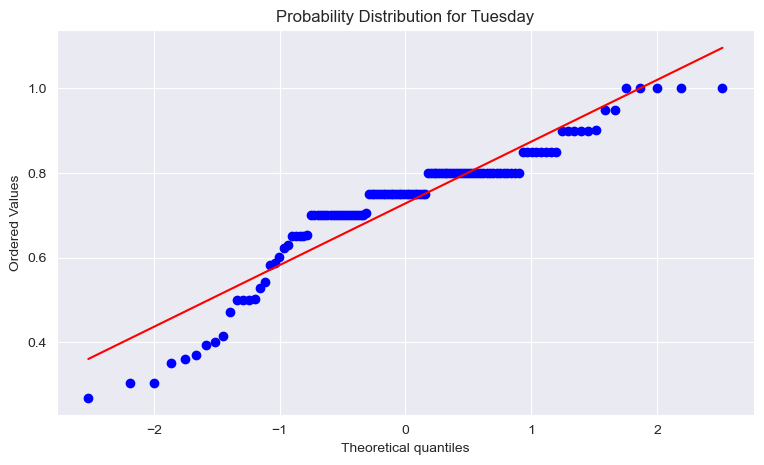

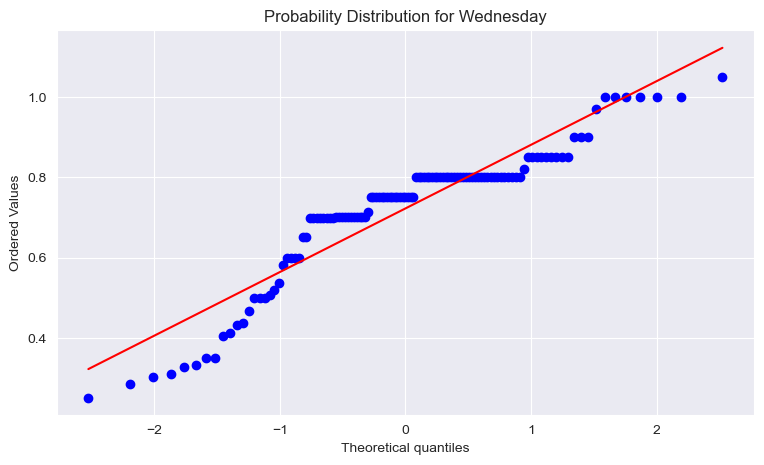

In [30]:
# Plot Probability distribution for each Day of the week as each day can have different distributions.
for day in prod_df.day.unique():
    plt.figure(figsize=(9,5))
    stats.probplot(prod_df["actual_productivity"][prod_df.day == day], plot=plt)  
    plt.title(f"Probability Distribution for {day}")

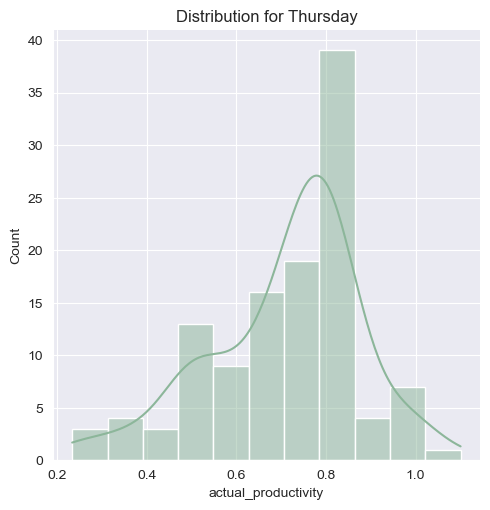

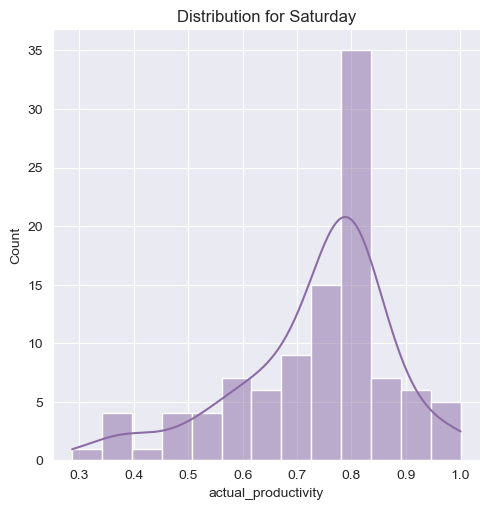

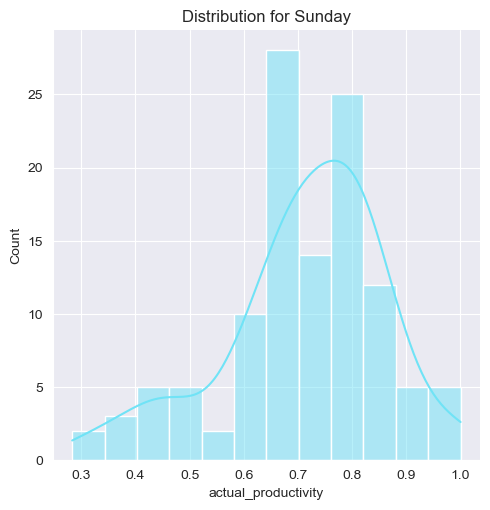

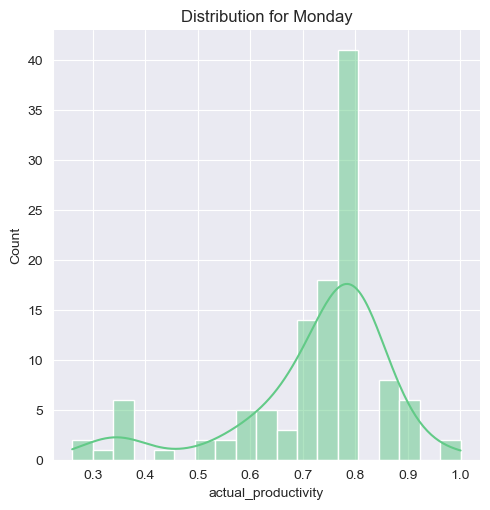

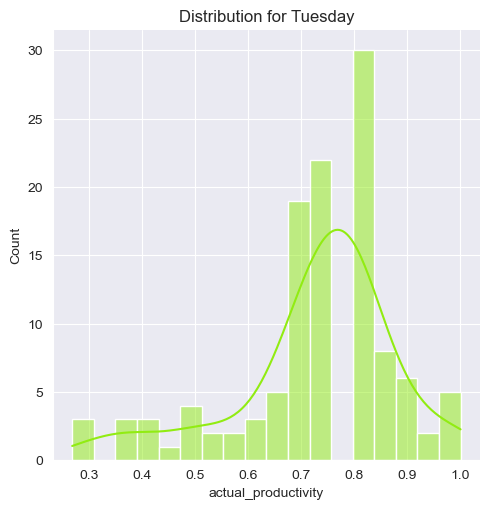

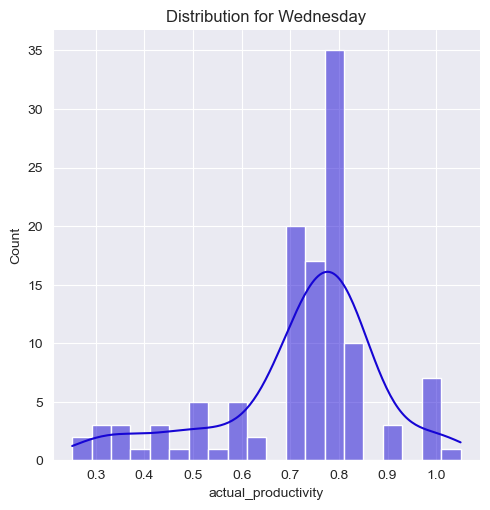

In [31]:
np.random.seed(0)
for day in prod_df.day.unique():
    sns.displot(prod_df.actual_productivity[prod_df.day == day],
                kde=True, 
                color=(np.random.rand(1)[0], np.random.rand(1)[0], np.random.rand(1)[0]))  # Gives different colors to the plots.
    plt.title(f"Distribution for {day}")

### Shapiro Results:
Given that we want to test the normality of the data for each day, we can perform the Shapiro test for the productivity on each day of the week. We consider alpha = 0.05. For all of the Shapiro tests below, we can see that all of the p_values < alpha,  therefore we would reject the null hypothesis which states that the data from each group is normally distributed, because it is not and we could say that there is statistical evidence that shows a not normal distribution in the data. However for the sake of the exercise we will still proceed to the next stage as if the data was normaly distributed and check the variances.

In [32]:
for day in prod_df.day.unique():
    print(day, ": ", stats.shapiro(prod_df.actual_productivity[prod_df.day == day]))

Thursday :  ShapiroResult(statistic=0.9448016154685062, pvalue=0.00010524227225556716)
Saturday :  ShapiroResult(statistic=0.9101538658029198, pvalue=2.9793722596295404e-06)
Sunday :  ShapiroResult(statistic=0.9442652950602765, pvalue=0.00011122691951572891)
Monday :  ShapiroResult(statistic=0.8328640097825084, pvalue=3.923383209352012e-10)
Tuesday :  ShapiroResult(statistic=0.8985324559458889, pvalue=2.001336249833521e-07)
Wednesday :  ShapiroResult(statistic=0.887329960656262, pvalue=5.1426826776564324e-08)


### Levene test
We perform the Levene test to compare the variance between different groups and check whether there is any statistical significant difference between the groups variance. We take alpha as 0.05

* H0: There is no significant statistical difference between the variances of each day
* H1: There is significant statistical difference between the variances

In [33]:
days_list = [prod_df["actual_productivity"][prod_df.day == day] for day in prod_df.day.unique()]

In [34]:
levene_results = stats.levene(days_list[0], days_list[1], days_list[2], days_list[3], days_list[4], days_list[5], center="mean")

In [35]:
levene_results

LeveneResult(statistic=0.9656409528402914, pvalue=0.4380143378422362)

### Levene Results:
Because the p_value (0.438) is bigger than alpha (0.05) we fail to reject the null hypothesis because there is not enough evidence to say that the variances are different. Now we can perform the ANOVA test.

### OLS regression and Anova


In [36]:
model = ols("actual_productivity ~ day", data=dataframe).fit()
aov = sm.stats.anova_lm(model, type=2)
aov

,df,sum_sq,mean_sq,F,PR(>F)
day,5.0,0.043356,0.008671,0.36025,0.8757
Residual,685.0,16.487793,0.024070,NaN,NaN


### ANOVA Results:

As we are interested in perceiving whether there is a day where the productivity is significantly different than the others, we will pay close attention to the day sum square and the day mean square rather than their residuals because the day sum squared and the mean squared are the values regarding the difference between the different groups. Since the day sum squared and mean squared are very small this indicates that there is a very small variablility between the averages of days productivity. As the p-value (0.8757) > alpha (0.05) we fail to reject the null hypothesis because there is no sufficient evidence to prove significant statistical difference in productivity between the days of the week.

#### More explaination:
On the line plot of productivity of each day we could see that all the days of the week follow the same trend with slight differences, thus the day sum square makes sense because as I mentioned before it represents the differences between different groups. On the other hand, the residual sum square is bigger because as we can see the values within each day varies a lot, making sense this value being so big comparing to the one of the day. Since the F-statistic is resulting of the ratio of the day mean_square with the residual mean_squared, then a smaller F-statistic means that variances of values between the days (groups) is smaller than the variances of values within each day which means that the differences between each day are not so relevant. Then the p_value confirms this probability of the f-statistic.

# Question 3
What are the factors that influence employee’s productivity?

## Getting a Quick understanding of the nature of the columns:
This is so as to better decide what actions to take such as one-hot encoding or labeling encoding. Also due to the EDA performed in the beginning we know that the data is not normally distributed so we will have to normalise the data as well. Also perform feature selection before normalising the data otherwise the data may lose the relationship between the predictor features and the target feature.

In [37]:
for c in dataframe.columns:
    print(f"{c, dataframe[c].nunique()}" if dataframe[c].nunique() > 20 else f"{c, dataframe[c].unique()}")

('department', array(['sweing'], dtype=object))
('day', array(['Thursday', 'Saturday', 'Sunday', 'Monday', 'Tuesday', 'Wednesday'],
      dtype=object))
('team', array([ 8, 11, 12,  6,  7,  3,  2,  1,  9, 10,  5,  4]))
('targeted_productivity', array([0.8 , 0.75, 0.7 , 0.65, 0.6 , 0.35, 0.5 , 0.07, 0.4 ]))
('smv', 62)
('wip', 548)
('over_time', 130)
('incentive', 42)
('idle_time', array([  0. ,  90. , 150. , 270. , 300. ,   2. ,   5. ,   8. ,   4.5,
         3.5,   4. ,   6.5]))
('idle_men', array([ 0, 10, 15, 45, 37, 30, 35, 20, 25, 40]))
('no_of_style_change', array([0, 1, 2]))
('no_of_workers', 39)
('actual_productivity', 463)


We can drop department as every observation shares the same department

In [38]:
dataframe.iloc[:,2:].corr()

,team,targeted_productivity,smv,wip,over_time,incentive,idle_time,idle_men,no_of_style_change,no_of_workers,actual_productivity
team,1.000000,0.001386,-0.365552,-0.033474,-0.179306,-0.162500,0.002950,0.031670,-0.028691,-0.369144,-0.125099
targeted_productivity,0.001386,1.000000,-0.024535,0.062054,-0.083653,0.486399,-0.066868,-0.060030,-0.250372,-0.079154,0.697970
smv,-0.365552,-0.024535,1.000000,-0.037837,0.256689,-0.091340,0.028672,0.044322,0.113344,0.577504,-0.155676
wip,-0.033474,0.062054,-0.037837,1.000000,0.022302,0.167210,-0.026299,-0.048718,-0.072357,0.030383,0.131147
over_time,-0.179306,-0.083653,0.256689,0.022302,1.000000,0.106006,-0.003519,-0.129017,-0.232519,0.345692,-0.016875
incentive,-0.162500,0.486399,-0.091340,0.167210,0.106006,1.000000,-0.109222,-0.196299,-0.323594,0.079584,0.804149
idle_time,0.002950,-0.066868,0.028672,-0.026299,-0.003519,-0.109222,1.000000,0.557675,-0.027712,0.036820,-0.113737
idle_men,0.031670,-0.060030,0.044322,-0.048718,-0.129017,-0.196299,0.557675,1.000000,0.110131,0.050224,-0.258357
no_of_style_change,-0.028691,-0.250372,0.113344,-0.072357,-0.232519,-0.323594,-0.027712,0.110131,1.000000,0.146899,-0.281686
no_of_workers,-0.369144,-0.079154,0.577504,0.030383,0.345692,0.079584,0.036820,0.050224,0.146899,1.000000,0.003378


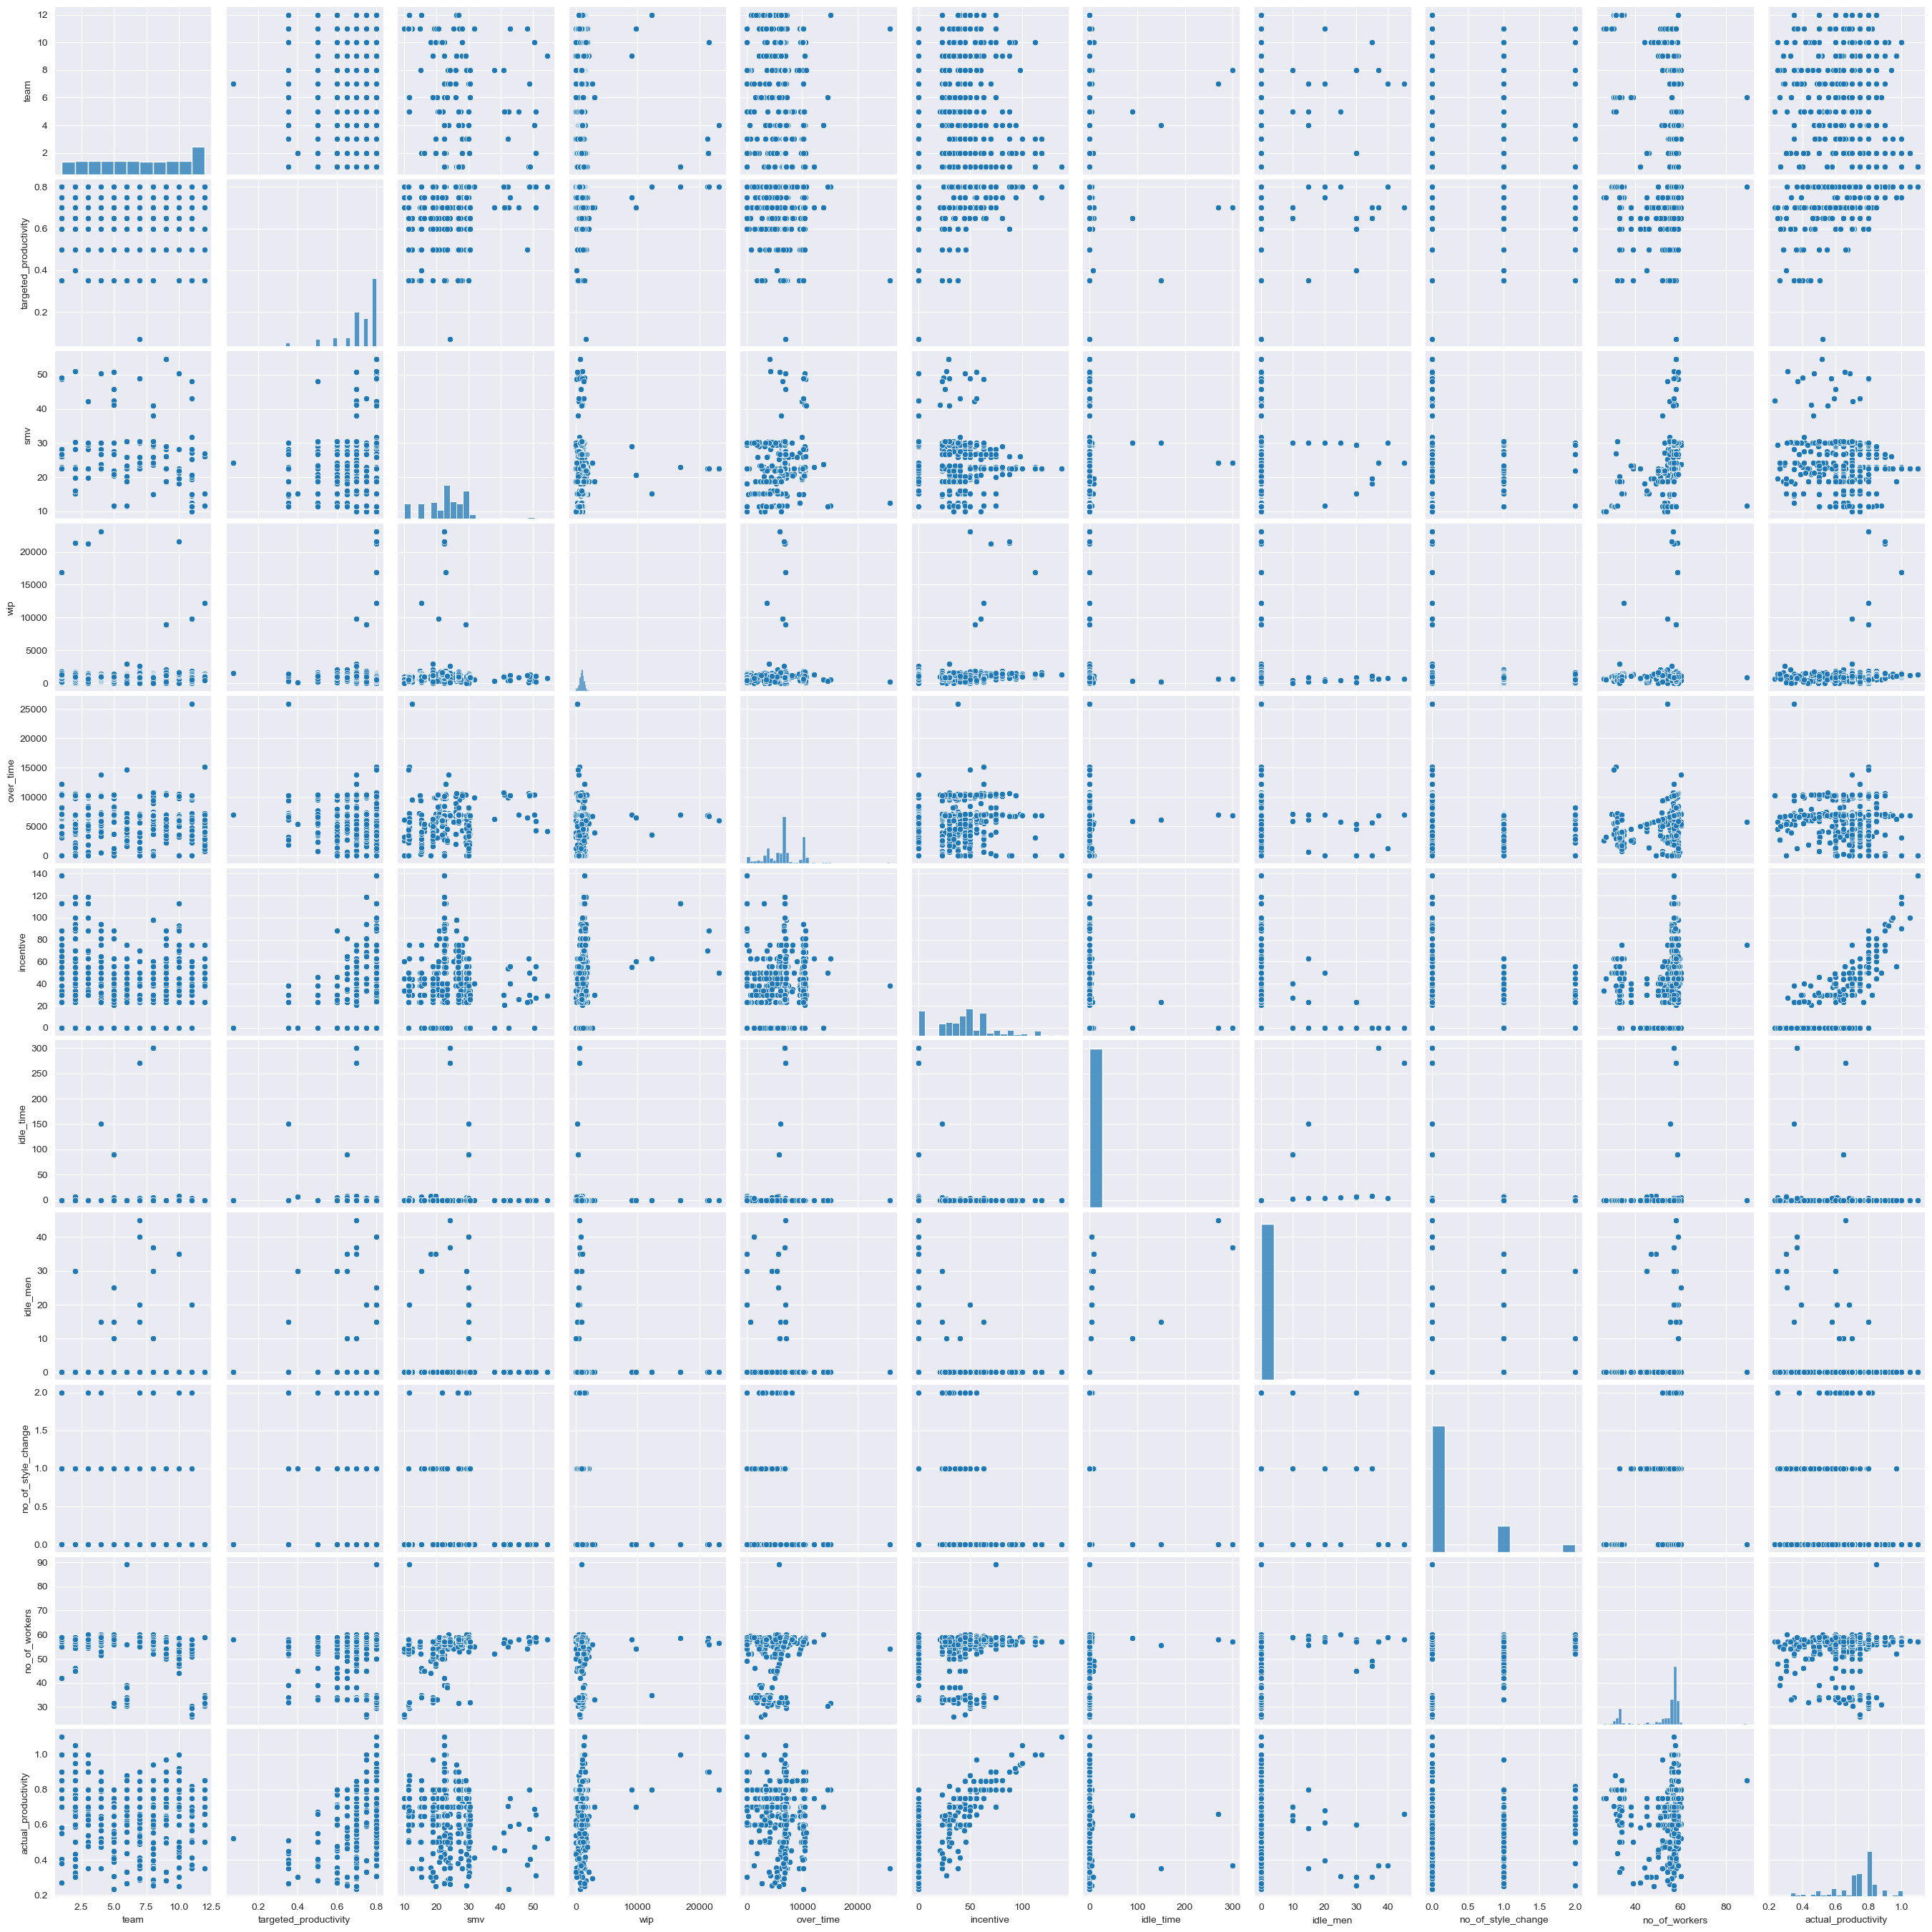

In [39]:
sns.pairplot(dataframe.iloc[:,2:])

As we can see above incentive seems to have a positive and stronger correlation with the actual productivity. 

In [40]:
dataframe.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 691 entries, 0 to 690
Data columns (total 13 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   department             691 non-null    object 
 1   day                    691 non-null    object 
 2   team                   691 non-null    int64  
 3   targeted_productivity  691 non-null    float64
 4   smv                    691 non-null    float64
 5   wip                    691 non-null    int64  
 6   over_time              691 non-null    int64  
 7   incentive              691 non-null    int64  
 8   idle_time              691 non-null    float64
 9   idle_men               691 non-null    int64  
 10  no_of_style_change     691 non-null    int64  
 11  no_of_workers          691 non-null    float64
 12  actual_productivity    691 non-null    float64
dtypes: float64(5), int64(6), object(2)
memory usage: 70.3+ KB


### Encoding 
I will create a new dataframe with new encoded features and drop features that are not needed any longer. I will also drop 'department' as it is the same throughout all of the data and it doesn't convey any meaningful information for our Analysis. Since the features that I am going to encode are nominal data and don't show an order I will use one-hot encoding method. I could also use the pandas.get_dummies() method for this.

In [41]:
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder

In [42]:
encoder = OneHotEncoder()
encode_team = encoder.fit_transform(dataframe[["team"]]).toarray()
encode_team_df = pd.DataFrame(encode_team, columns=encoder.get_feature_names_out(["team"]))

In [43]:
encode_day = encoder.fit_transform(dataframe[["day"]]).toarray()
encode_day_df = pd.DataFrame(encode_day, columns=encoder.get_feature_names_out(["day"]))

In [44]:
encode_style_change = encoder.fit_transform(dataframe[["no_of_style_change"]]).toarray()
encode_style_change_df = pd.DataFrame(encode_style_change, columns=encoder.get_feature_names_out(["no_of_style_change"]))

In [45]:
new_df = pd.concat([dataframe.drop(["department", "day", "team", "no_of_style_change"], axis=1), encode_day_df, encode_team_df, encode_style_change_df], axis=1)

<Axes: >

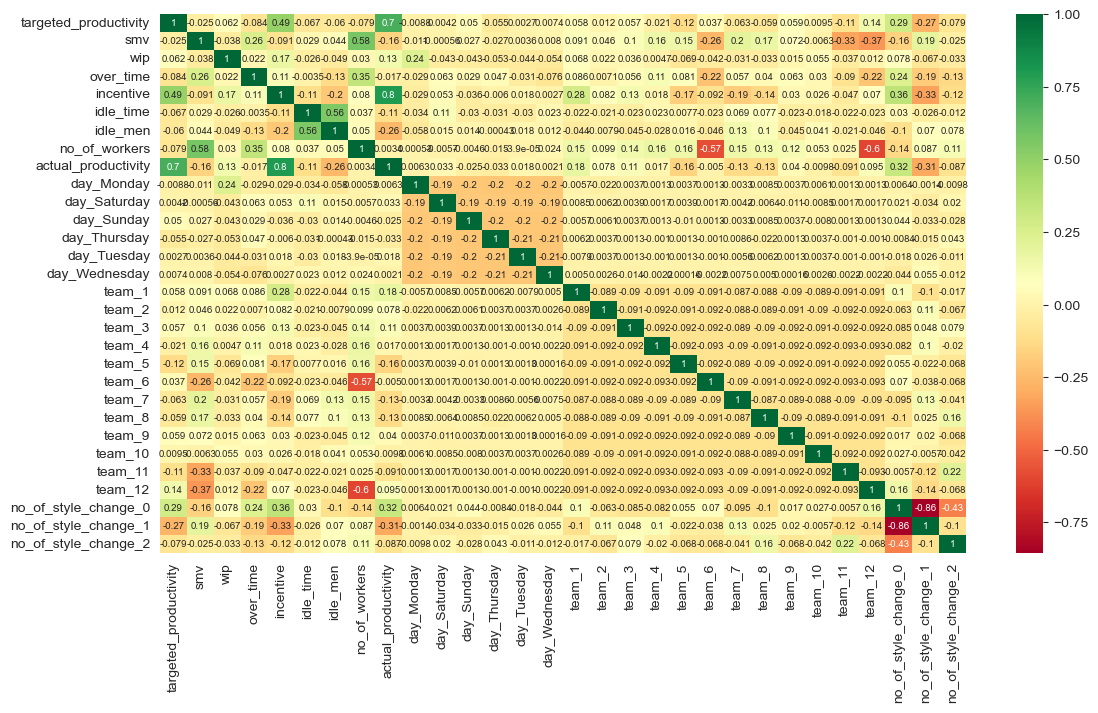

In [46]:
plt.figure(figsize=(13, 7))
sns.heatmap(new_df.corr(), annot=new_df.corr(), annot_kws={"size":7}, cmap="RdYlGn")

As per the heatmap above the actual productivity has a positive moderate correlations with 'no_of_ style_ change_0' and 'targeted productivity' and a strong positive correlation with 'incentive'. Whereas the most relevant negative correlations with our target are 'no_of_style_change_1', 'idle men' and 'number of style change' with moderate and week correlations with our target variable. 

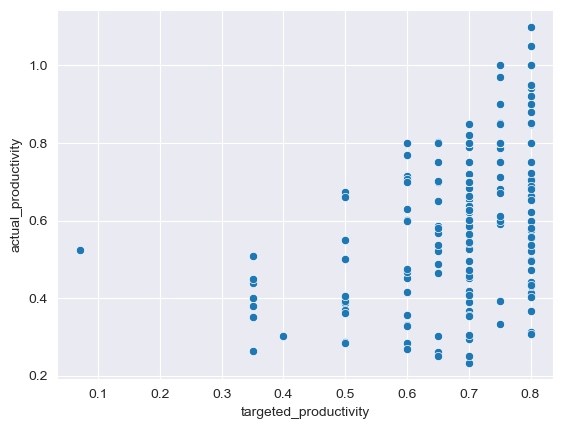

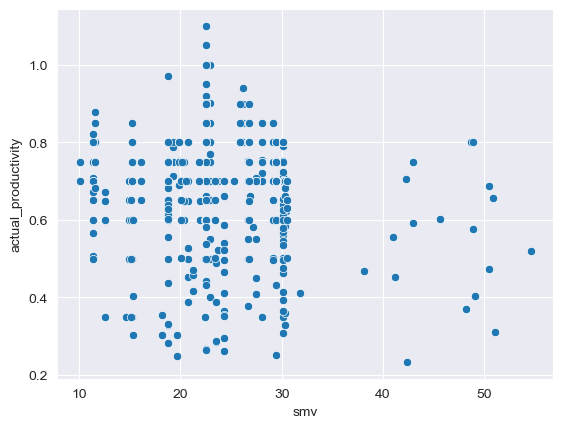

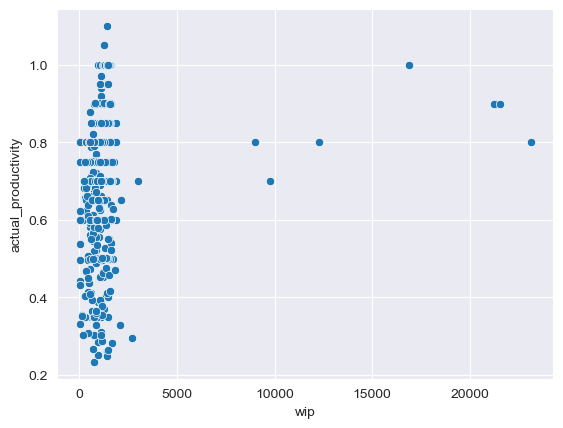

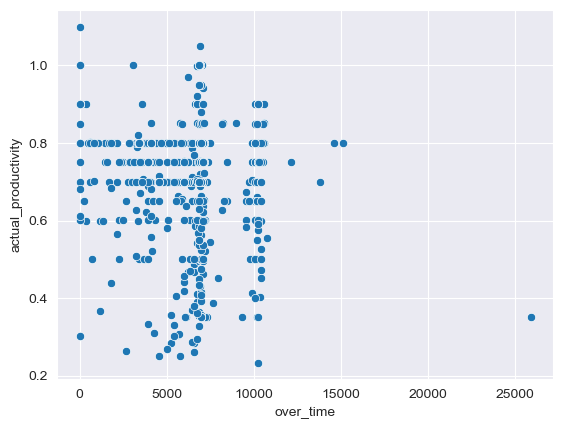

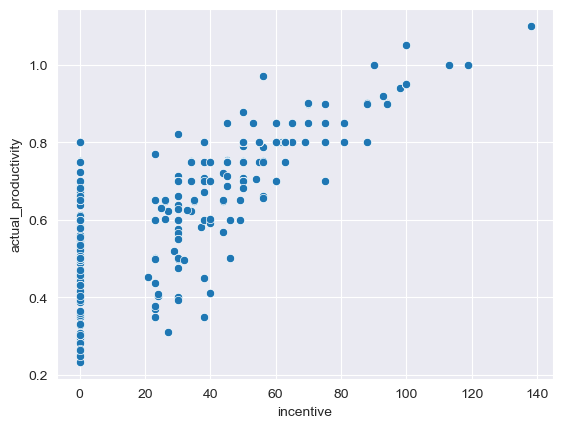

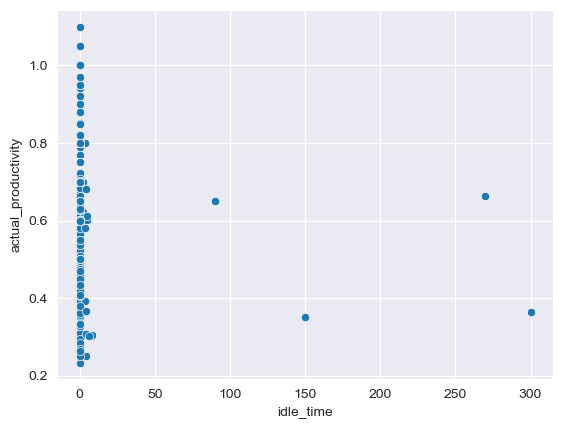

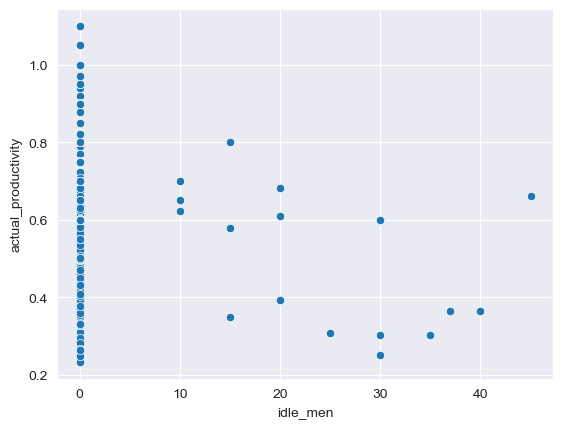

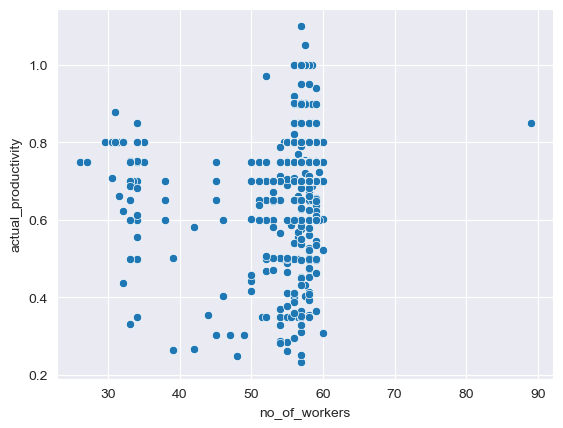

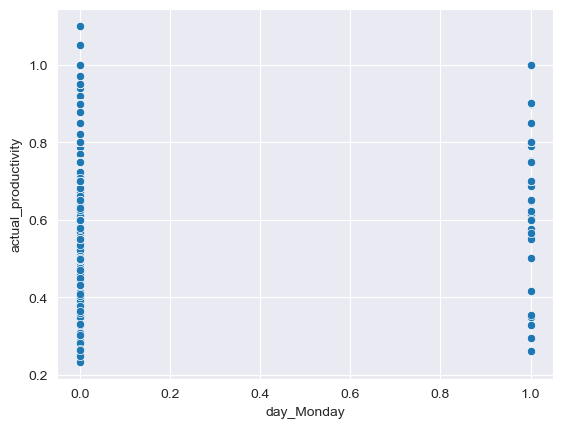

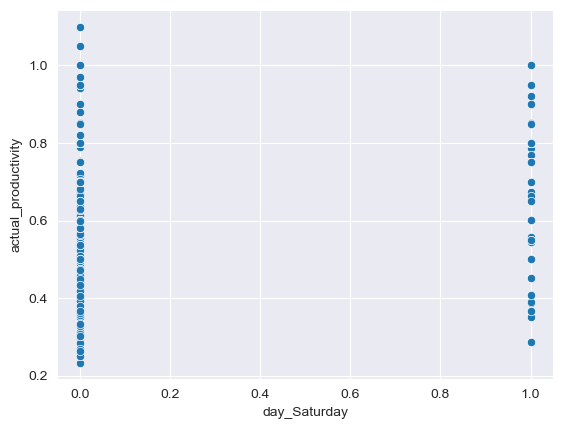

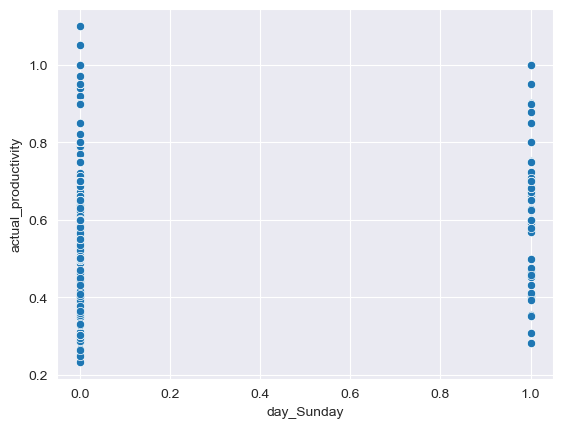

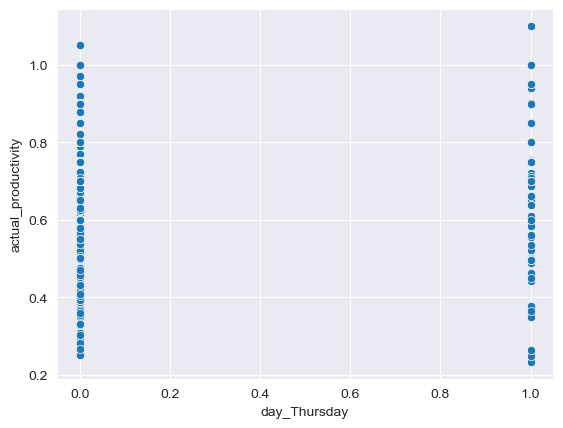

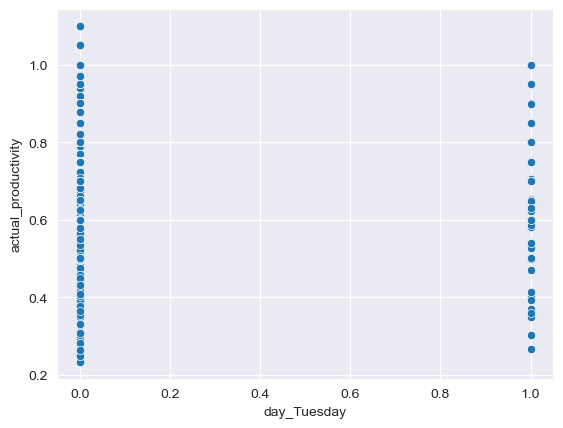

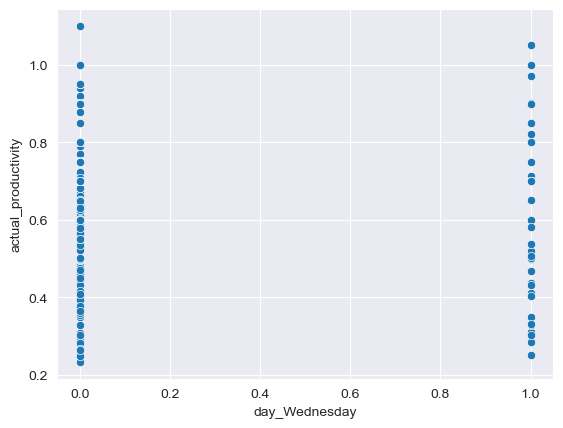

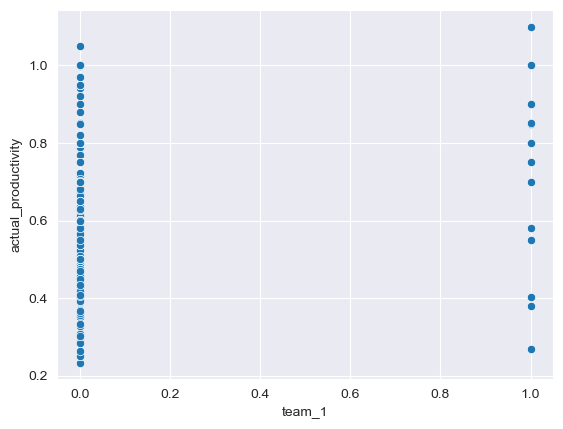

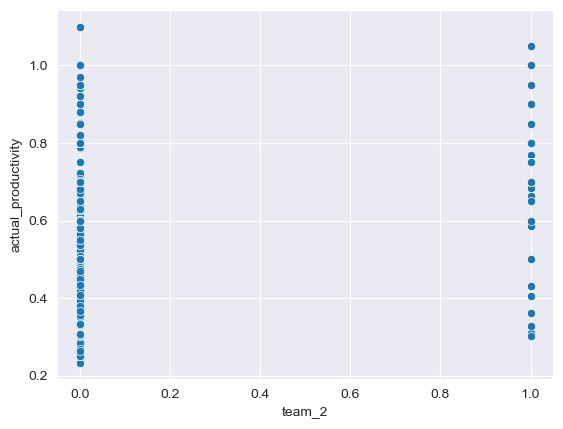

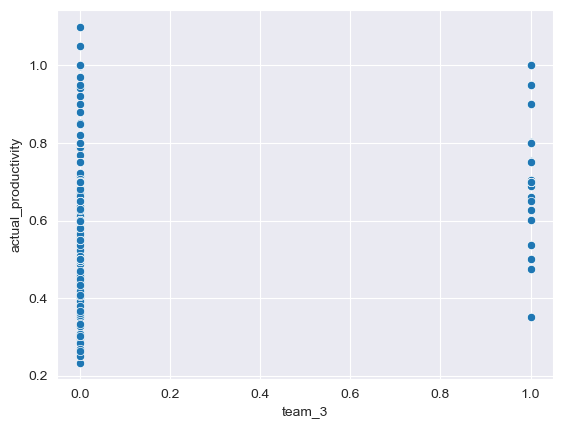

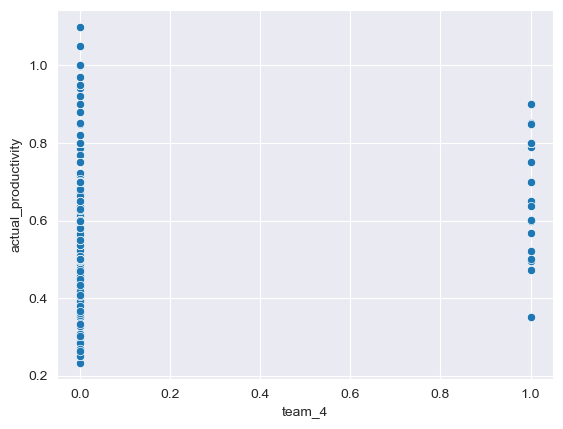

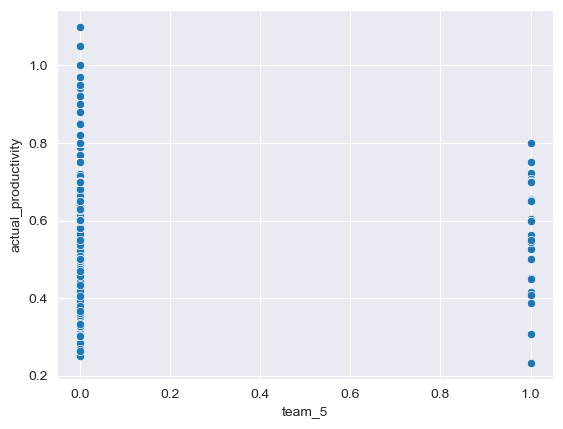

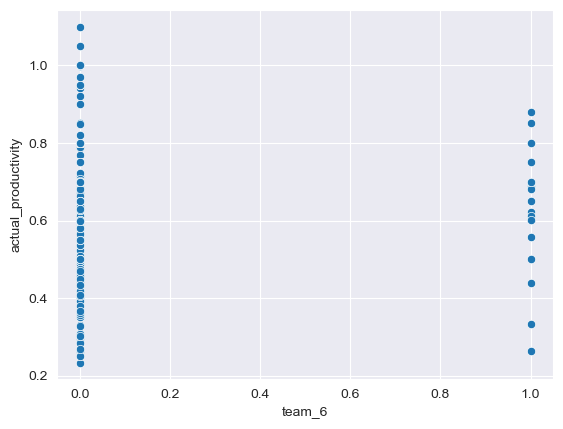

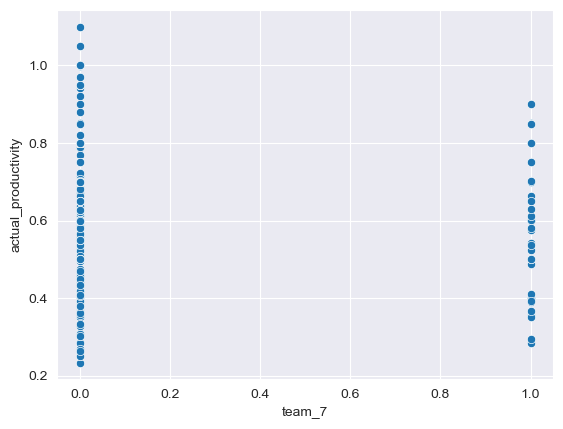

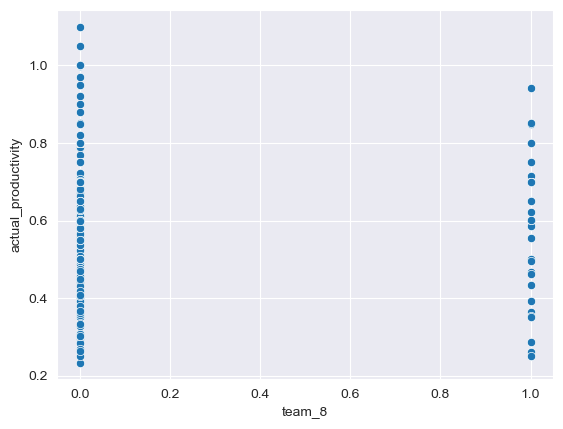

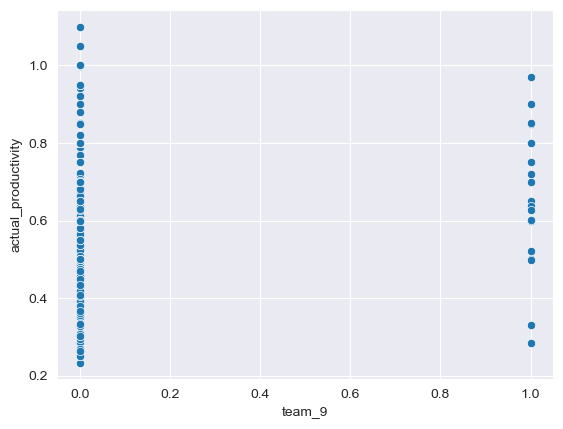

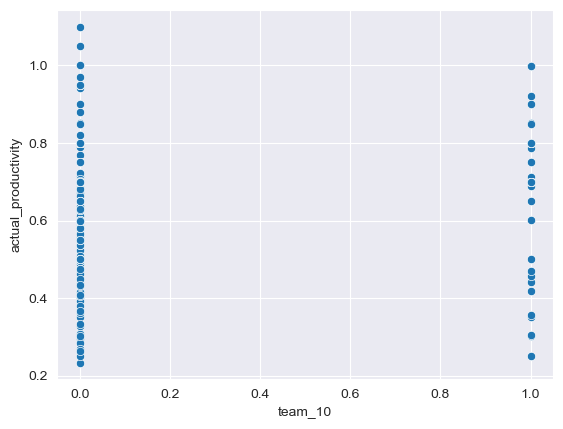

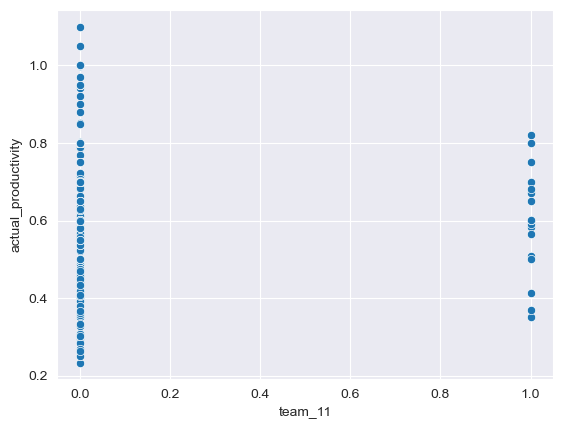

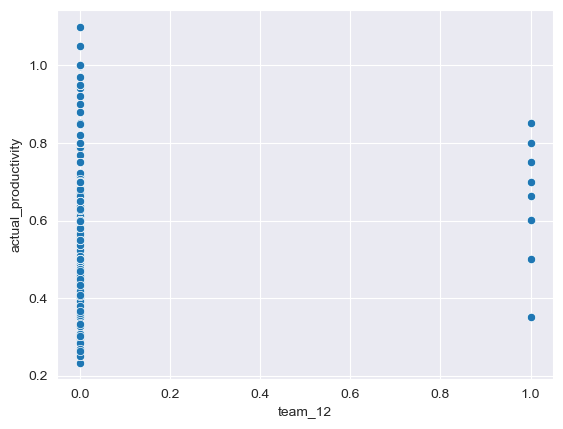

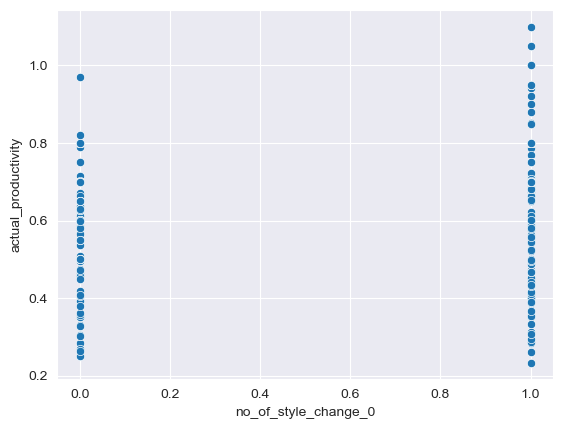

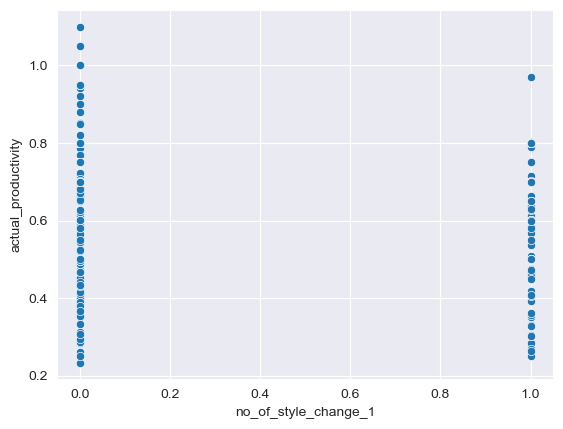

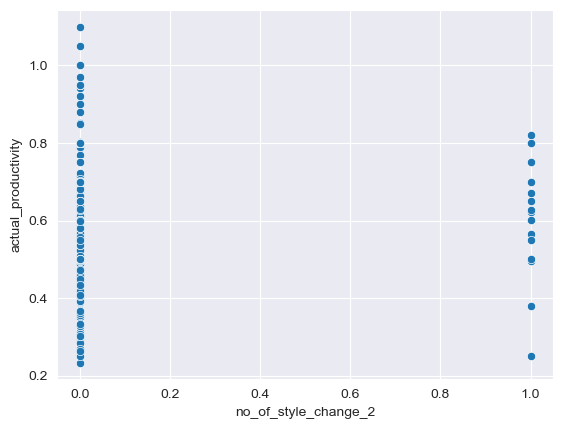

In [47]:
for c in new_df.drop("actual_productivity", axis=1).columns:
    sns.scatterplot(new_df, x=c, y="actual_productivity")
    plt.show()

# Feature Selection
As I said before, before normalising the features that are not in a scale between 0 and 1, I will first proceed with the feature selection. This way I can assure that the relationships between the features and target are preserved at the time of the feature selection to later benefit my regression model. I also want to check which score function will provide the best feature selection for my model. According to the visualisations performed before (the scatter plots), the only features that seem to have a linear relationship with the 'actual productivity' feature are the 'incentive' and the 'targeted productivity' (just a little bit). Therefore I will utilize two different feature selection score functions: the f_regression for linear relationships and the mutual_info_regression for non linear relationships and see which one selects the best features for my model. I chose mutual_info_regression because most of the feature don't seem to have a linear relationship with the target variable.

In [48]:
from sklearn.feature_selection import SelectKBest, f_regression, mutual_info_regression

In [49]:
X = new_df.drop("actual_productivity", axis=1)
y = new_df[["actual_productivity"]]

# Using f_regression as a score function
# I am using k=10 because this was the value with which my Random Forest model reached highest value
select1 = SelectKBest(score_func=f_regression, k=10)  
best1 = select1.fit(X, y)

/opt/anaconda3/lib/python3.12/site-packages/sklearn/utils/validation.py:1300: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


#### Key features influencing the employee's productivity using the score function f_regression
As we can see the first 5/6 seem to be the most relevant so 5/6 could be a good number for K with this score function (which ends up not being exacly the case)

In [50]:
scores_df = pd.concat([pd.DataFrame(X.columns, columns=["Columns"]), pd.DataFrame(best1.scores_, columns=["Scores"])], axis=1)
scores_df.nlargest(15, columns="Scores")  # This selects the top 15 features according to the score function

,Columns,Scores
4,incentive,1260.936128
0,targeted_productivity,654.503533
26,no_of_style_change_0,80.897430
27,no_of_style_change_1,71.917236
6,idle_men,49.278894
14,team_1,22.759566
18,team_5,17.547736
1,smv,17.112754
2,wip,12.057836
20,team_7,11.470273


#### Key features influencing the employee's productivity using the score function mutual_info_regression
As we can see the first 5 seem to be the most relevant so 5 could be a good number for K with this score function (which ends up not being exacly the case)

In [51]:
# Using Mutual info regression as a score function
select2 = SelectKBest(score_func=mutual_info_regression, k=10)
select2.fit(X, y)

scores_df2 = pd.concat([pd.DataFrame(X.columns, columns=["Columns"]), pd.DataFrame(select2.scores_, columns=["Scores"])], axis=1)
scores_df2.nlargest(15, columns="Scores") 

/opt/anaconda3/lib/python3.12/site-packages/sklearn/utils/validation.py:1300: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


,Columns,Scores
4,incentive,1.401889
1,smv,0.938105
0,targeted_productivity,0.898058
3,over_time,0.895254
7,no_of_workers,0.754468
26,no_of_style_change_0,0.115867
25,team_12,0.113755
2,wip,0.111371
27,no_of_style_change_1,0.108124
22,team_9,0.087742


### Model
Here I import 3 different models to see which one performs the best. I could also have utilised a polinomial model of higher order to see if that fits and explains better the non-linear relationships that the data appears to have between the features and the target. 

In [ ]:
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

#### Normalization
In the line just below we can see that 'actual_productivity' will also need normalisation as it has values bigger than 1 (which is our threshold).

In [53]:
new_df["actual_productivity"].sort_values(ascending=True).nlargest(15)

426    1.100484
342    1.050281
307    1.000671
318    1.000602
295    1.000457
354    1.000446
308    1.000402
414    1.000345
427    1.000345
272    1.000230
262    1.000230
438    1.000230
448    1.000230
459    1.000230
261    1.000230
Name: actual_productivity, dtype: float64

In [54]:
scaler = MinMaxScaler()
norm_features = scaler.fit_transform(new_df.iloc[:,:9])  # Array with the normalised values

In [55]:
norm_features_df = pd.DataFrame(norm_features, columns=scaler.get_feature_names_out())  # DataFrame with the normalised features

In [56]:
norm_df = pd.concat([norm_features_df, new_df.iloc[:,9:]], axis=1)  # A Full dataframe with all the values normalised 

In [57]:
norm_df

,targeted_productivity,smv,wip,over_time,incentive,idle_time,idle_men,no_of_workers,actual_productivity,day_Monday,day_Saturday,day_Sunday,day_Thursday,day_Tuesday,day_Wednesday,team_1,team_2,team_3,team_4,team_5,team_6,team_7,team_8,team_9,team_10,team_11,team_12,no_of_style_change_0,no_of_style_change_1,no_of_style_change_2
0,1.000000,0.361941,0.047631,0.273148,0.710145,0.0,0.0,0.523810,0.815687,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1,1.000000,0.030555,0.041575,0.141204,0.362319,0.0,0.0,0.071429,0.653991,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0
2,1.000000,0.030555,0.041575,0.141204,0.362319,0.0,0.0,0.071429,0.653991,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0
3,1.000000,0.356100,0.050314,0.074074,0.362319,0.0,0.0,0.476190,0.653773,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,1.000000,0.356100,0.042267,0.259259,0.275362,0.0,0.0,0.476190,0.653477,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
686,0.931507,0.376769,0.045295,0.273148,0.326087,0.0,0.0,0.523810,0.595706,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
687,0.863014,0.376769,0.042613,0.268519,0.217391,0.0,0.0,0.507937,0.538605,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
688,0.863014,0.458998,0.039239,0.263889,0.217391,0.0,0.0,0.492063,0.538546,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
689,0.863014,0.300157,0.048497,0.175926,0.289855,0.0,0.0,0.190476,0.538247,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [58]:
# Here I select the features as calculated by the model selector score functions
X1 = norm_df[norm_df.drop("actual_productivity", axis=1).columns[select1.get_support()]]
X2 = norm_df[norm_df.drop("actual_productivity", axis=1).columns[select2.get_support()]]

# This is the Target variable
y = norm_df["actual_productivity"]

#### Model Selection

In [59]:
X_train1, X_test1, y_train, y_test = train_test_split(X1, y, train_size=.8, random_state=0)

# Since we only need the values for x_train and x_test when using the mutual info regression we don't need to overwrite the y values.
X_train2, X_test2, *_ = train_test_split(X2, y, train_size=.8, random_state=0) 

In [60]:
models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(),
    "Random Forest": RandomForestRegressor()
}

np.random.seed(11)
# With the feature from the f_regression function
for name, model in models.items():
    model.fit(X_train1, y_train)
    y_pred = model.predict(X_test1)
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    print(f"Results for {name}:\nR-squared: {r2}\nMean Square Error: {mse}\nMean Absolute Error: {mae}\n\n")

Results for Linear Regression:
R-squared: 0.739139001939396
Mean Square Error: 0.009551554974351187
Mean Absolute Error: 0.05850399527846083


Results for Decision Tree:
R-squared: 0.7173680619950578
Mean Square Error: 0.01034870875075947
Mean Absolute Error: 0.04882973953101252


Results for Random Forest:
R-squared: 0.8109133032016813
Mean Square Error: 0.006923503294149103
Mean Absolute Error: 0.04552915365091915




In [61]:
# With the feature from the mutual_info_regression
np.random.seed(11)
for name, model in models.items():
    model.fit(X_train2, y_train)
    y_pred = model.predict(X_test2)
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    print(f"Results for {name}:\nR-squared: {r2}\nMean Square Error: {mse}\nMean Absolute Error: {mae}\n\n")

Results for Linear Regression:
R-squared: 0.7745660743727689
Mean Square Error: 0.008254375125913021
Mean Absolute Error: 0.05691061266811319


Results for Decision Tree:
R-squared: 0.7371175881836917
Mean Square Error: 0.00962557004274801
Mean Absolute Error: 0.048220267327611234


Results for Random Forest:
R-squared: 0.8487550271552431
Mean Square Error: 0.005537909781305551
Mean Absolute Error: 0.04240853792634475




As we can see above for the mutual_info_regression features all the models perform better than with the features from the f_regression. This is also influenced by the random states that I assign to the codes and the different values I assigned to K parameter where 10 was the best parameter to utilise giving higher scores specially for the Random Forest, the best performing model for this data with an R-squared of 0.8487. Assigning to k either the values 5 or 10 didn't seem to make a big difference since as we saw earlier 5 could be a good number for the model even though 10 showed to be the best performant.


### Model Selection Using Cross Validation
This will help prevent overfitting and reduce the bias in the sampling.

In [ ]:
from sklearn.model_selection import cross_val_score, KFold

# The cross-validation strategy
kf = KFold(n_splits=5, shuffle=True, random_state=11)

models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(),
    "Random Forest": RandomForestRegressor(random_state=11)
}

# Results for the mutual_info_regression
print("Results for the mutual_info_regression:/n")
for name, model in models.items():
    # cross_val_score returns one score per fold — negative MSE by convention
    scores = cross_val_score(model, X2, y, cv=kf, scoring="r2")
    
    print(f"{name}")
    print(f"  R² per fold: {scores.round(3)}")
    print(f"  Mean R²:     {scores.mean():.4f}")
    print(f"  Std R²:      {scores.std():.4f}  ← smaller is more stable\n")

# Results for the f1 regression
print("/n/nResults for the f1 regression:/n")
for name, model in models.items():
    scores = cross_val_score(model, X1, y, cv=kf, scoring="r2")
    
    print(f"{name}")
    print(f"  R² per fold: {scores.round(3)}")
    print(f"  Mean R²:     {scores.mean():.4f}")
    print(f"  Std R²:      {scores.std():.4f}  ← smaller is more stable\n")

# Text Report of Analysis

This analysis was conducted with the aim of analysing and understanding the productivity of the employees of a company and how different factors affect the values of the productivity, overtime and consequently the costs of running the company. By preprocessing the data and conducting an Exploratory Data Analysis it was much easier to understand the data and later I could benefit from that by choosing the most appropriate approach for each given context. In this step I could understand even though there were no missing values or duplicates, I had categorical variables that should be converted into numerical variables and my variables were not normally distributed. This had to be then addressed later.

The first question answered  was with regards to how the implementation of new machines would benefit the company by reducing the costs associated with the overtimes of the employees. The key here was to understand the question, have a good understanding of the fundamentals and use case of different statistical approaches and properly formulate the hypothesis. Since I wanted to objectively assure whether there was or not enough evidence in the sample to support the belief or claim of the company, knew that I had to perform a one-sample statistical test either t-test or z-test. Here I stumbled across the first hurdle: The data was not normally distributed and as parametric test, t-test and z-test, have some assumptions such as normal distribution of the data, which I knew that the data was not normally distributed due to the EDA performed. However, since my sample size what big enough (200) I could still proceed given that according to the Central Limit Theorem as the sample size increases the data distribution approximates a normal distribution. If that was not the case I could have performed a non-parametric test (Mann-Whitney U Test (McClenaghan, 2024)).

The second question was concerning whether there was any difference between the productivity for each day of the week. Given that I wanted to understand if there was any statistical difference between more than 2 groups ( the 6 days of the week) for one factor (Actual Productivity), I needed to perform a One-Way ANOVA test. However, before performing the ANOVA test I had to ensure 3 factors otherwise the results could not be accurate and correct for the given context and another methods and tests should be utilized. I had to check: Sample Independence; Variables Normal Distribution; Approximate same variance between variables. Then I came across the second hurdle: As per the graph I plotted and can also be found below, each day seems to display a cyclicity which suggests that sample independence may not be fulfilled. Because of the fact that the values for each day behave the same with similar oscillations, and when the minimum values for each oscillation is reached it is followed by a maximum value. This suggest dependence in the samples.

 
Due to this phenomenon, to proceed with the analysis and eventually perform an ANOVA test I had to ignore this and consider the samples independent. But I could rather have performed a non-parametric test instead of the ANOVA test such as the Friedman test (McClenaghan, 2024).

By proceeding with the analysis another hurdle was raised. The data was not normally distributed. To proceed I should have either performed a non-parametric test like the Friedman test or use a function to normalize the distribution of the data such as the logarithmic function or even the square root function depending on my aim. I still conducted the analysis and performed the ANOVA test which revealed there be no significant difference in productivity between the different days of the week. Nevertheless, I knew this values were not the most accurate given the context of the data.

Finally, for the last question selecting the features influencing the most the productivity of the employees and performing regression analysis, was one of the most enjoyable part of this analysis. 
Here, normalising the data would be very beneficial when I create the model but before normalising the features I first had to proceed with the feature selection. This way I could assure that the relationships between the features and target were preserved at the time of the feature selection to later benefit my regression model. I also wanted to check which score function for the SelectKBest class would provide the best feature selection for my model. I knew that according to the visualisations performed before (the scatter plots), the only features that seem to have a linear relationship with the 'actual productivity' feature were the 'incentive' and the 'targeted productivity'. Therefore, I utilized two different feature selection score functions: the ‘f_regression’ for linear relationships and the ‘mutual_info_regression’ for non-linear relationships and see which one would select the best features for my model. I chose ‘mutual_info_regression’ because most of the feature didn’t seem to have a linear relationship with the target variable. The model which performed the best was the Random Forest with the features suggested by the ‘mutual_info_regression’ score function, hyperparameter k=10 and a score of 84.87% of R-squared suggesting that the Random Forest explains 84.87% of the variance on the data. 

Overall, the analysis went very well and the aims were attained even though having into consideration that some approaches would have been well beyond the scope of this analysis and as a matter of simplicity and showing accomplishment of the learning outcomes of the module I had to simplify the steps and make assumptions that in a real case shouldn’t have been made and I am cognizant of that. With this analysis I could also understand how critical the choice of our approach is for the success of the analysis.

Thank you!

Jonilson António
